# Assignment: Missed Medical Appointment Data Analysis & Autonomous Rescheduling Agent

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Preprocessing</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusion">Conclusion Of EDA</a></li>
<li><a href="#model">Predictive Model Development</a></li>
<li><a href="#deployment">Model Deployment And Integration</a></li>
</ul>

<a id='intro'></a>
## Introduction




> **Medical Appointment No Shows Dataset Analysis:**
This Dataset has information about more than 11 thousand patients in Brazil. It contains their medical history information and we need to investigate this dataset to find out factors that affect patients attendance to the scheduled appointment. The main questions that we want to focus on is: What makes patients failing to attend their hospital appointment?

 **Dataset columns descriptions:**


 * PatientId - Patient identification.
 * AppointmentID - Appointment identification. 
 * Gender -  Patient's gender (Male or Female).
 * ScheduledDay - The day patient set up their appointment.
 * AppointmentDay - The day of actual appointment when patient have to visit the doctor.
 * Age - Patient's Age
 * Neighbourhood - Hospital location.
 * Scholarship - Indicates whether or not the patient is enrolled in Brasilian welfare program Bolsa Família(0 for no & 1 for Yes).
 * Hipertension - Indicates whether or not the patient has hypertension or not(0 for no & 1 for Yes).
 * Diabetes - Indicates whether or not the patient has diabetes or not (0 for no & 1 for Yes).
 * Alcoholism - Indicates whether or not the patient has alcoholism or not (0 for no & 1 for Yes).
 * Handicap - Indicates whether or not the patient has handicap or not (on scale from 0 to 4)
 * SMS_received = Indicates whether or not the patient received a SMS reminder (0 for no & 1 for Yes)
 * No-show = Indicates whether or not the patient attend the appointment(Yes for didn't show, No for show)


 **Dataset columns descriptions:**
 * Gender - Patient's gender (Male or Female).
 * Scheduled_day - The day patient set up their appointment.
 * Appointment_day - The day of actual appointment when patient have to visit the doctor.
 * Age - Patient's Age
 * Neighbourhood - Hospital location.
 * Scholarship - Indicates whether or not the patient is enrolled in Brasilian welfare program Bolsa Família (0 for no & 1 for Yes).
 * Hipertension - Indicates whether or not the patient has hypertension (0 for no & 1 for Yes).
 * Diabetes - Indicates whether or not the patient has diabetes (0 for no & 1 for Yes).
 * Alcoholism - Indicates whether or not the patient has alcoholism (0 for no & 1 for Yes).
 * Handcap - Indicates whether or not the patient has a handicap (on a scale from 0 to 4).
 * SMS_received - Indicates whether or not the patient received a SMS reminder (0 for no & 1 for Yes).
 * Show - Target Variable. Indicates whether the patient attended the appointment (1 for Attended, 0 for Missed).
 * Wait_days - Engineered Feature. The number of days between scheduling and the actual appointment.
 * historical_no_show_rate - Engineered Feature. The patient's historical rate of missing appointments prior to the current visit.


> **Research Questions:**
Because our target variable (`Show`) measures attendance (1 = Attended), our EDA will calculate the mean of this column to determine the **Probability of Attendance** across different demographics.

 * 1 - Does Gender affect attendance rates? (Attendance probability of Males vs. Females)
 * 2 - How does Alcoholism affect the probability of attendance?
 * 3 - How does Hypertension affect the probability of attendance?
 * 4 - How does a Handicap affect the probability of attendance?
 * 5 - How does Diabetes affect the probability of attendance?
 * 6 - How does welfare enrollment (Scholarship) affect the probability of attendance?
 * 7 - Do SMS reminders successfully increase the probability of attendance?
 * 8 - How do Age and Wait_days correlate with appointment attendance?
 * 9 - How does a patient's historical no-show rate impact their likelihood of attending a future appointment?



### Importing Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import datetime
sns.set_style("darkgrid")

<a id='wrangling'></a>
## Data Preparation

   **This is a three step process:**

*  Gathering the data from the dataset and investegate it in order to understand more details about it. 


*  Assessing data to identify any issues with data types, structure, or quality.


*  Cleaning data by changing data types, replacing values, removing unnecessary data and modifying Dataset for easy and fast analysis.



### General Properties (Data Accessment & Preview)

In [2]:
# Loading CSV file in to main Dataframe variable

df = pd.read_csv(r"C:\Users\This\Downloads\Assignment\Dataset\Medical Appointment No Shows.csv")

In [3]:
# Checking first 5 rows from Dataframe

df.head(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
# Checking Dataframe shape (number of rows and columns)

df.shape

(110527, 14)

In [5]:
# Checking the basic informations from loaded data (columns names, number of values, data types ......)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
# Checking more information and descriptive statistics

df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [7]:
# Checking more descriptive statistics for categorical data

df[["No-show","Gender","ScheduledDay","AppointmentDay","Neighbourhood"]].describe()

,No-show,Gender,ScheduledDay,AppointmentDay,Neighbourhood
count,110527,110527,110527,110527,110527
unique,2,2,103549,27,81
top,No,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI
freq,88208,71840,24,4692,7717


In [8]:
# Checking for NaN values

df.isnull().sum().sum()

0

In [9]:
# Checking for duplicated rows

df.duplicated().sum()

0

In [10]:
# Checking rows which have negative Age 

df_negative_age = df.query("Age<0")
df_negative_age

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


#### Summary: 
* There are no NaN values in any column.
* There are no duplicated rows
* There are one row with negative age value which is not valid

### Data Cleaning 
 
 *  Data that needs modification or changing:

    1.  Dropping [AppointmentID] as it is a primary key
    2.  There's one record of Age value -1 and this is not logical so the entire row is dropped
    3.  Change [ScheduledDay and AppointmentDay] columns names to [Scheduled_day and Appointment_day] to enhance readability.
    4.  Change [ScheduledDay and AppointmentDay] types to Datetime to extract days from them
    5.  Appointment_Day column has no hours or minutes so hours and minutes are added to calculate waiting days accurately
    6.  Create new column (Wait_days) that indicates the difference days between scheduled day and appointment day
    7.  Change new column (Wait_days) type to int
    8.  Changing No-show column name to (Show).
    9.  Reverse all data inside Show column to be more clear:
           -  A. (1 will mean patient attended) 
           -  B. (0 will mean patient didn't attend)
    10. Change Show column type to int
    11. Engineered a historical_no_show_rate feature from PatientId before dropping the column.
    


In [11]:
# (1) Dropping AppointmentID

df.drop(["AppointmentID"], axis= 1 , inplace= True)

In [12]:
# (2) Dropping any row with age value less than 0

df.drop(df_negative_age.index, inplace = True)

In [13]:
# Checking that Age column has been dropped

df.query("Age<0")

,PatientId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show


In [14]:
# (3) Fixing columns names and separate words by "_"

# (4) Changing Scheduled Date and Appointment Date data types to datetime

columns_names = ["ScheduledDay", "AppointmentDay"]
for col in columns_names:
    df[col] = pd.to_datetime(df[col])
    df.rename(columns = {col : col[:-3]+"_day"}, inplace=True)

In [15]:
# Checking changes 

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   PatientId        110526 non-null  float64            
 1   Gender           110526 non-null  object             
 2   Scheduled_day    110526 non-null  datetime64[ns, UTC]
 3   Appointment_day  110526 non-null  datetime64[ns, UTC]
 4   Age              110526 non-null  int64              
 5   Neighbourhood    110526 non-null  object             
 6   Scholarship      110526 non-null  int64              
 7   Hipertension     110526 non-null  int64              
 8   Diabetes         110526 non-null  int64              
 9   Alcoholism       110526 non-null  int64              
 10  Handcap          110526 non-null  int64              
 11  SMS_received     110526 non-null  int64              
 12  No-show          110526 non-null  object             
dtypes: d

In [16]:
# (5) Added hours and minutes to Appointment_Day column to calculate waiting days accurately

df["Appointment_day"] =  df["Appointment_day"] + pd.Timedelta('1d') - pd.Timedelta('1s')

# (6) Create new column (Wait_days) that indicates the difference days between scheduled day and appointment day
# (7) Change new column (Wait_days) type to int

df["Wait_days"] = (df["Appointment_day"] - df["Scheduled_day"] ).dt.days.astype(int)

In [17]:
# Checking types of columns data

df.dtypes

PatientId                      float64
Gender                          object
Scheduled_day      datetime64[ns, UTC]
Appointment_day    datetime64[ns, UTC]
Age                              int64
Neighbourhood                   object
Scholarship                      int64
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
SMS_received                     int64
No-show                         object
Wait_days                        int32
dtype: object

##### Details about new column "wait_days"

* If wait_days == 0 appointment day & scheduled day are same - Ontime
* If wait_days < 0 appointment day before scheduled day - Early appointment 
* If wait_days > 0 appointment day after scheduled day - Delay appointment

In [18]:
# Checking Noshow column value_counts

df["No-show"].value_counts()

No-show
No     88207
Yes    22319
Name: count, dtype: int64

In [19]:
# (8) Changing No-show column name to (Show) and &  make sure all columns names has no spaces on the first

df.rename(columns = {"No-show" : "Show"}, inplace=True)
df.rename(columns = lambda x : x.strip(), inplace=True)

In [20]:
# (9) Reverse all data inside Show column to be more clear

df["Show"] = df["Show"].apply(lambda x : 1 if x =="No" else 0 )

In [21]:
# (10) Change Show column type to int

df["Show"] = df["Show"].astype(int)

In [22]:
# Checking for show column value_counts

df["Show"].value_counts()

Show
1    88207
0    22319
Name: count, dtype: int64

In [23]:
# (11) Creating a historical_no_show_rate feature from PatientId before dropping the column

# Sort by PatientId and Appointment_day chronologically
df = df.sort_values(by=['PatientId', 'Appointment_day'])

# Create a temporary column to flag missed appointments
df['is_missed'] = (df['Show'] == 0).astype(int)

# Calculate cumulative past appointments for each patient
df['past_appointments'] = df.groupby('PatientId').cumcount()

# Calculate cumulative past missed appointments
# We subtract the current row's 'is_missed' status so we don't accidentally use today's result to predict today's appointment (preventing data leakage)
df['past_no_shows'] = df.groupby('PatientId')['is_missed'].cumsum() - df['is_missed']

# Calculate the historical no-show rate (Fill NaN with 0 for a patient's first-ever visit)
df['historical_no_show_rate'] = (df['past_no_shows'] / df['past_appointments']).fillna(0)

# Now it is safely calculated, we can drop PatientId and the temporary columns
df.drop(['PatientId', 'is_missed', 'past_appointments', 'past_no_shows'], axis=1, inplace=True)

In [24]:
# Check the new feature alongside your Target column

# Sort the dataframe by the new feature in descending order
df_verification = df.sort_values(by='Appointment_day', ascending=False)

# Reset the index so it counts cleanly from 0, 1, 2, 3... and drop the old messy index
df_verification.reset_index(drop=True, inplace=True)

# Display the top 20 results (to verify that the historical_no_show_rate is calculated correctly and aligns with the Show column)
display(df_verification[['historical_no_show_rate', 'Show']].head(20))

,historical_no_show_rate,Show
0,0.000000,1
1,0.500000,1
2,0.500000,1
3,0.200000,1
4,0.000000,1
5,1.000000,1
6,0.000000,1
7,0.000000,1
8,0.000000,1
9,0.000000,1


In [25]:
# Final prepared dataset

df_verification.head(20)

,Gender,Scheduled_day,Appointment_day,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Show,Wait_days,historical_no_show_rate
0,F,2016-05-31 13:45:23+00:00,2016-06-08 23:59:59+00:00,61,JARDIM CAMBURI,0,0,0,0,0,0,1,8,0.000000
1,F,2016-06-06 17:17:26+00:00,2016-06-08 23:59:59+00:00,17,MARIA ORTIZ,0,0,0,0,0,0,1,2,0.500000
2,F,2016-06-08 08:34:09+00:00,2016-06-08 23:59:59+00:00,55,SÃO JOSÉ,0,1,0,0,0,0,1,0,0.500000
3,M,2016-06-01 13:57:18+00:00,2016-06-08 23:59:59+00:00,11,CONQUISTA,0,0,0,0,0,1,1,7,0.200000
4,M,2016-05-11 09:56:25+00:00,2016-06-08 23:59:59+00:00,7,JARDIM DA PENHA,0,0,0,0,0,1,1,28,0.000000
5,M,2016-06-08 07:51:25+00:00,2016-06-08 23:59:59+00:00,56,DA PENHA,0,1,0,1,0,0,1,0,1.000000
6,F,2016-06-03 10:49:41+00:00,2016-06-08 23:59:59+00:00,57,SÃO CRISTÓVÃO,0,0,0,0,0,1,1,5,0.000000
7,F,2016-06-08 14:08:58+00:00,2016-06-08 23:59:59+00:00,37,ROMÃO,1,0,0,0,0,0,1,0,0.000000
8,F,2016-05-25 09:11:34+00:00,2016-06-08 23:59:59+00:00,11,JARDIM CAMBURI,0,0,0,0,0,1,1,14,0.000000
9,F,2016-06-03 07:26:32+00:00,2016-06-08 23:59:59+00:00,53,SANTO ANDRÉ,0,0,0,0,0,1,1,5,0.000000


<a id='eda'></a>
## Exploratory Data Analysis

> Now we are going to explore this data and try to find patterns in it, compute statistics and visualize the relationships
to answer the questions and detect the characteristics that affect patients attending to their hospital appointment


### Research Question 1
> #### Does Gender affect the attendance?
        - Ratio for Males who attended
        - Ratio for Females who attended

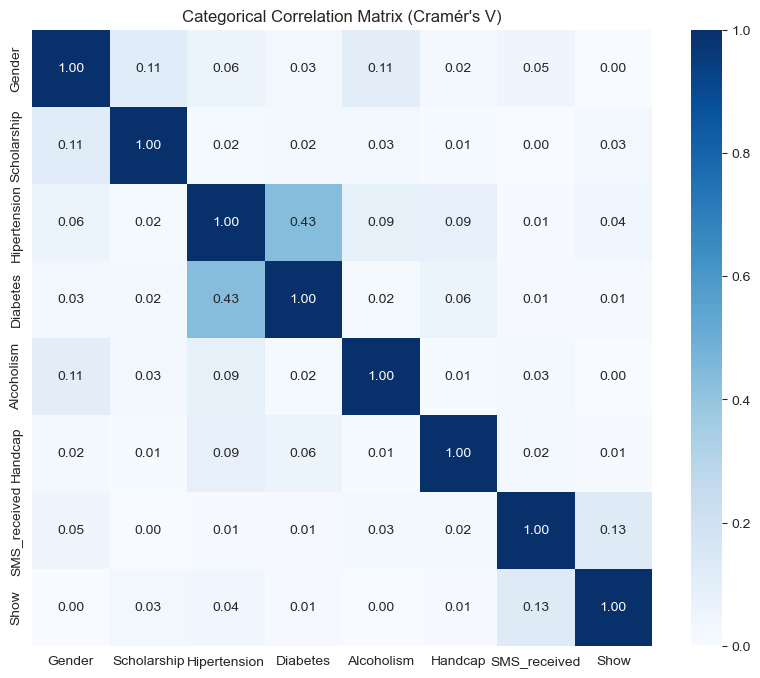

In [26]:
import numpy as np
import scipy.stats as ss
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define Cramer's V function for categorical correlation
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Updated list: using 'Show' instead of 'No-show'
cat_vars = ['Gender', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'Show']

# Create an empty matrix
corr_matrix = pd.DataFrame(index=cat_vars, columns=cat_vars)

# Populate the matrix with Cramer's V scores
for col1 in cat_vars:
    for col2 in cat_vars:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convert to float for seaborn
corr_matrix = corr_matrix.astype(float)

# Plot the mathematically correct heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Categorical Correlation Matrix (Cramér's V)")
plt.show()

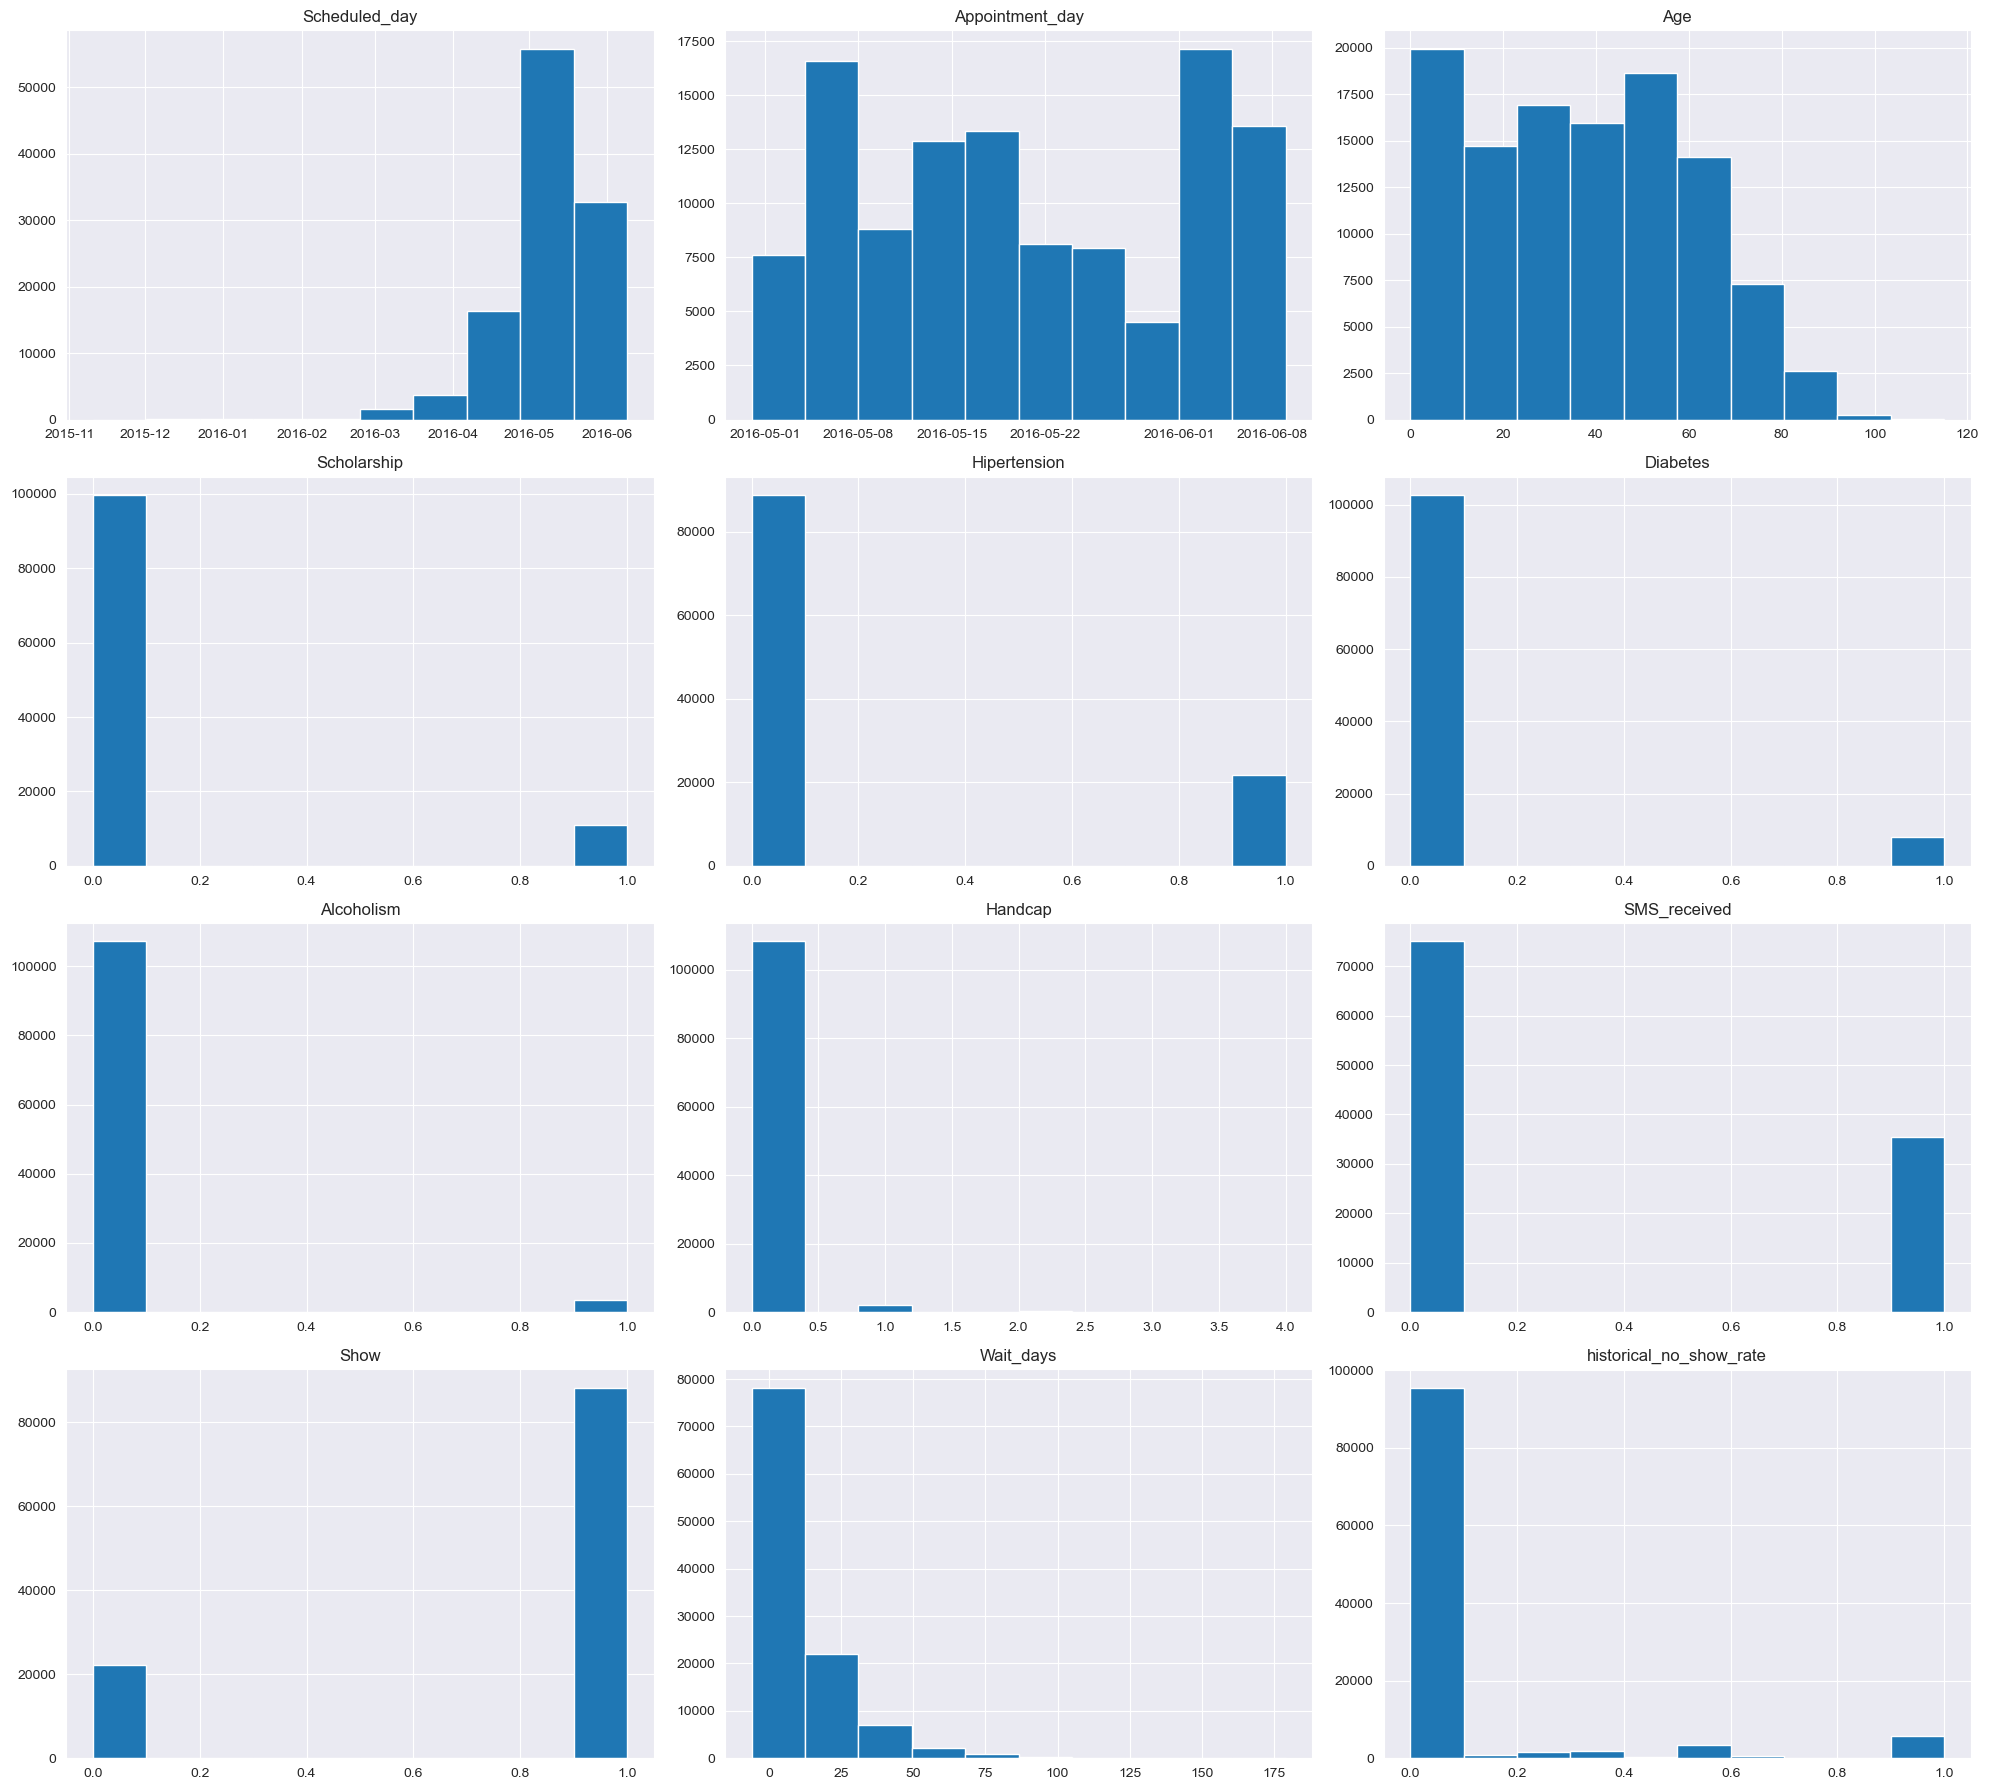

In [27]:
# Checking the skewness between columns data

df.hist(figsize=(20,18), alpha=1);
plt.tight_layout()
plt.show()

In [28]:
# Checking number of patients who attended and didn't attend

all_patients_count = df["Show"].value_counts()
all_patients_count

Show
1    88207
0    22319
Name: count, dtype: int64

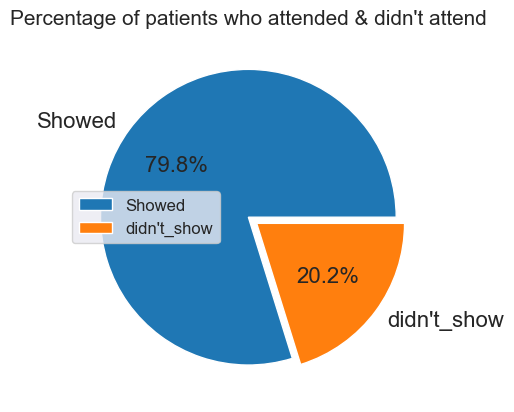

In [29]:
# Pie chart display of how many patient attended to appointment and how many didn't

plt.pie(all_patients_count,labels=["Showed", "didn't_show"], autopct='%1.1f%%', textprops={'fontsize': 16},explode = (0, 0.07))
plt.rcParams['font.size'] = 12
plt.title("Percentage of patients who attended & didn't attend",fontsize=15)
plt.legend()
plt.show()

**We can see that 79.8% from all patients already attended and 20.2% didn't attend**


In [30]:
# Make Dataframe with only showed patients and other for only patients didn't show

df_show = df.query("Show == 1")
df_no_show = df.query("Show == 0")

In [31]:
def proportions_fun (df,lst,col):
    """
    This function to calculate proportions for specific columns using groupby and value counts
    and returns the proportions if all input data are correct
    or print "You have entered wrong input" if there is wrong input
    
    INPUT: 
    - df1 : dataframe which contains all patients who attended and didn't
    - lst : list which contains columns names that we need to groupby (groupby will be sorted as the same lst values sort)
    - col :string with specific column name (which we want to calculate proportion according to it)
    OUTPUT:
    - proportion : it's a pandas Series that contains grouped by lst values and propotions according to col
    """
    try:
        if df.empty == True:
            raise Exception('data frame is empty')
        for i in lst: 
            if i not in df:
                raise Exception('one or more of columns in list are not part of the dataframe')
        proportion = df.groupby(lst)[col].value_counts(normalize=True).unstack(col)
        return proportion
    except Exception as error:
        print("You have entered wrong input " + repr(error))

In [32]:
# Function test

# Test 1: Correct data

expected = df.groupby(["Gender","Handcap"])["Show"].value_counts(normalize=True).unstack("Show")
found = proportions_fun(df, ["Gender","Handcap"], "Show")
expected.equals(found)

True

In [33]:
# Test 2: Incorrect column name

proportions_fun(df, ["Gender","Handcap"], "wrong_column_name")

You have entered wrong input KeyError('Column not found: wrong_column_name')


In [34]:
# Test 3: Incorrect list

proportions_fun(df, ["Gender","not_exsiting"], "Show")

You have entered wrong input Exception('one or more of columns in list are not part of the dataframe')


#### Now we use proportions_fun to calculate proportions for each factor trying to find correlations

In [35]:
# Males & Females proportions according to attended patients only (using proportions_fun)

gender_ratio = proportions_fun(df_show,["Show"],"Gender")
gender_ratio

Gender,F,M
Show,,
1,0.648985,0.351015


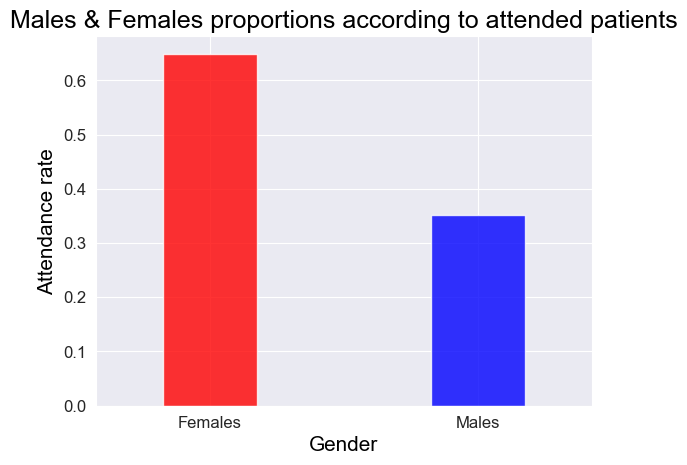

In [36]:
# Bar chart for Males & Females proportions according to attended patients only 

gender_ratio.unstack(False).plot(kind = "bar",
                                   rot = 0,
                                   width = 0.35,
                                   color=["r","b"],
                                   alpha = 0.8,
                                   fontsize = 12,
                                   )

plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Gender",fontsize=15, color="k")
plt.title("Males & Females proportions according to attended patients",fontsize=18, color="k")
labels = ["Females","Males"]
plt.xticks(range(len(labels)),labels);
#plt.figure(figsize=(8,5))
#plt.legend(["Attended"],fontsize=14);
plt.show()

**It's obvious that the attendance rate for females is higher than males. The attendance ratio is 64.9% for females and just 35,1% for males from all attended patients**

**To be more accurate we need to check the attendance ratio for males from all attended males against attendance ratio for females from all attended females**

In [37]:
# getting gender proportions using (proportions_fun)

gender_proportion = proportions_fun(df,["Gender"],"Show")
gender_proportion

Show,0,1
Gender,,
F,0.203149,0.796851
M,0.199679,0.800321


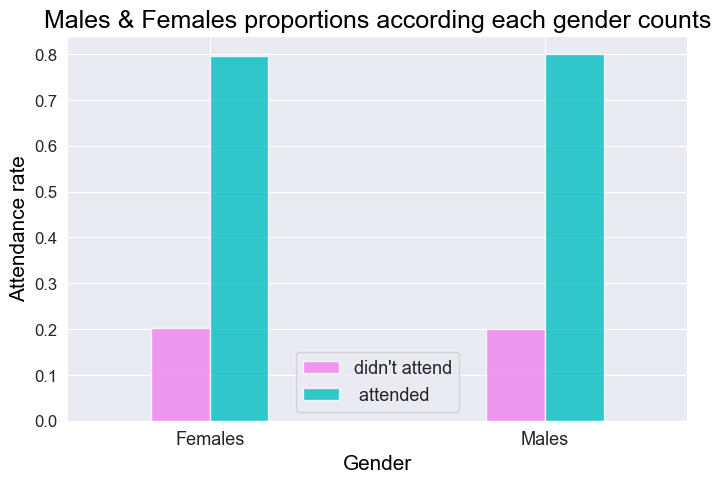

In [38]:
# Bar chart for showed males and females proportions according to each gender

gender_proportion.plot(kind = "bar",
                       rot = 0,
                       width = 0.35,
                       color=["violet","c"],
                       alpha = 0.8,
                       fontsize = 12,
                       figsize=(8,5)
                         )

plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Gender",fontsize=15, color="k")
plt.title("Males & Females proportions according each gender counts",fontsize=18, color="k")
labels = ["Females","Males"]
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()


### Answer 1
#### From first visualization we can clearly notice that Females usually have more appointments than Males patients. So gender might be an important factor. But as shown in the second visualization, the attendance rate was rather similar for both genders.
   - Percentage of Females who attended is 79.68% from all Females. 
   - Percentage of Males who attended is 80% from all Males.
   
(That means there's no direct correlation between gender and attendance & both genders have the same commitment to attend the medical appointment.)



### Research Question 2 
> #### How the Alcoholism affect probability of show up?
       - Ratio for patients who have alcoholism and attended the appointment.
       - Ratio for patients who don't have alcoholism and attended the appointment.
     
     

In [39]:
# Obtaining Alcoholism proportions using (proportions_fun)

alcoholism_proportions = proportions_fun(df,["Alcoholism"],"Show")
alcoholism_proportions

Show,0,1
Alcoholism,,
0,0.201948,0.798052
1,0.201488,0.798512


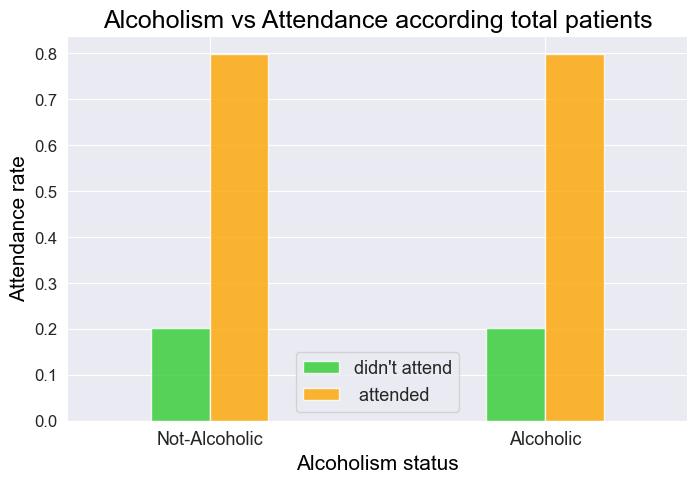

In [40]:
# Bar chart showed Alcoholic and not-Alcoholic proportions

alcoholism_proportions.plot(kind = "bar",
                            rot = 0,
                            width = 0.35,
                            color=["limegreen","orange"],
                            alpha = 0.8,
                            fontsize = 12,
                            figsize=(8,5)
                             )

plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Alcoholism status",fontsize=15, color="k")
plt.title("Alcoholism vs Attendance according total patients", fontsize=18, color="k") 
labels = ["Not-Alcoholic","Alcoholic"]
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()

### Answer 2
* From above visualisation we can conclude the attendance rate is rather similar for both clcoholic & non-alcoholic patients. They have relatively similar commitment to attend the medical appointment.
   - Percentage of Alcoholic patients who attended is 79.85% from all Alcoholic patients. 
   - Percentage of Not_Alcoholic patients who attended is 79.80% from all Not-Alcoholic patients 
   
(That means there's no direct correlation between alcoholism and attendance.)


### Research Question 3 
> #### How the Hypertension affect probability of show up?
     - Ratio for patients who have hypertension and attended the appointment.
     - Ratio for patients who don't have hypertension and attended the appointment.

In [41]:
# Obtaining Hypertension proportions using (proportions_fun)

hypertension_proportions = proportions_fun(df,["Hipertension"],"Show")
hypertension_proportions

Show,0,1
Hipertension,,
0,0.209039,0.790961
1,0.173020,0.826980


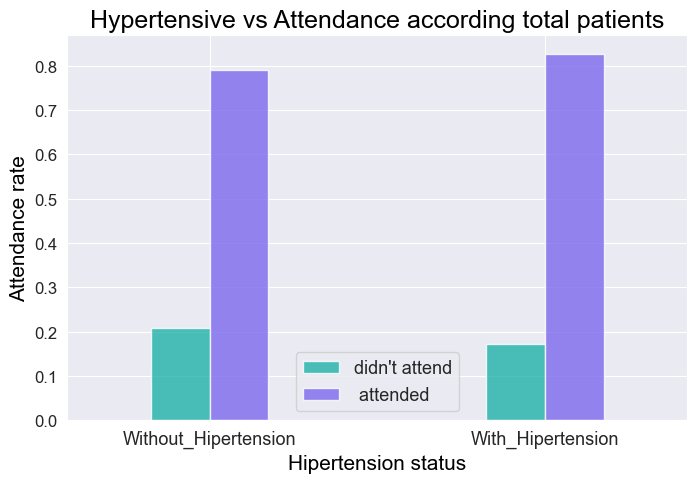

In [42]:
# Bar Chart for proportions of patients who have and don't have Hipertension according to total number of patients

hypertension_proportions.plot(kind = "bar",
                               rot = 0,
                               width = 0.35,
                               color=["lightseagreen","mediumslateblue"],
                               alpha = 0.8,
                               fontsize = 12,
                               figsize=(8,5)
                                 )

plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Hipertension status",fontsize=15, color="k")
plt.title("Hypertensive vs Attendance according total patients", fontsize=18, color="k") 
labels = ["Without_Hipertension","With_Hipertension"]
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()

### Answer 3

* From above visualisation we can conclude the attendance rate is rather similar for both patients who have hipertension and don't have hipertension. They have relatively similar commitment to attend the medical appointment.
   - Percentage of patients who have Hipertension and attended is 82.69% from all patients who have Hipertension. 
   - Percentage of patients who does not have Hipertension and attended is 79.09% from all patients who does not have Hipertension. 

(That means there's no direct correlation between hypertensive and attendance too.)


### Research Question 4 
> #### How the Handicap affect probability of show up?
     - Ratio for patients who have handicap and attended the appointment.
     - Ratio for patients who don't have handicap and attended the appointment.

In [43]:
# Obtaining Handcap proportions using (proportions_fun)

handcap_proportions = proportions_fun(df,["Handcap"],"Show")
handcap_proportions


Show,0,1
Handcap,,
0,0.202355,0.797645
1,0.179236,0.820764
2,0.202186,0.797814
3,0.230769,0.769231
4,0.333333,0.666667


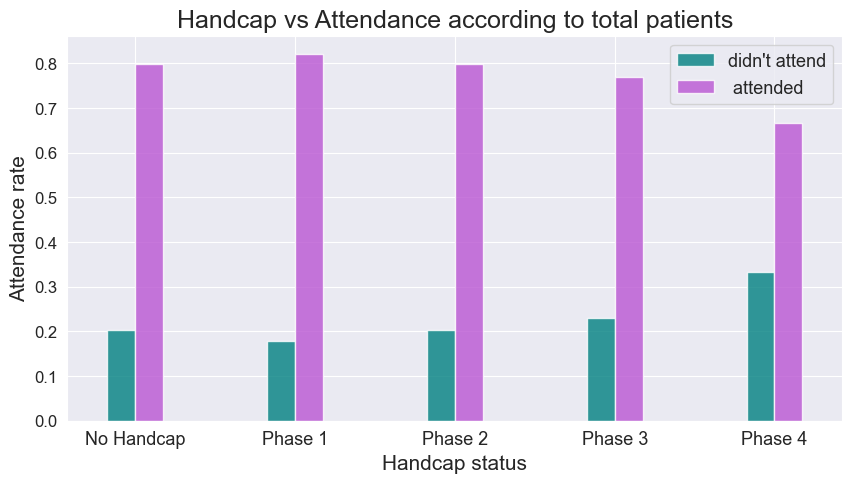

In [44]:
# Bar Chart for proportions of patients who have and don't have Handcap according to total number of patients

handcap_proportions.plot(kind = "bar",
                               rot = 0,
                               width = 0.35,
                               color=["teal","mediumorchid"],
                               alpha = 0.8,
                               fontsize = 12,
                               figsize=(10,5)
                                 )
plt.ylabel("Attendance rate", fontsize=15)
plt.xlabel("Handcap status", fontsize=15)
plt.title("Handcap vs Attendance according to total patients", fontsize=18)
labels = ['No Handcap', 'Phase 1','Phase 2','Phase 3','Phase 4']
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()

From above visualisation we can clearly see that the Handcap 4 patients have the lowest attending ratio (66.66%) but to be sure from the correlation we must check count number for all Handcap phase 4 patients.

In [45]:
df.query("Handcap == 4")["Handcap"].count()

3

### Answer 4

* From above visualisations the attendance rate is rather similar for patients who have Handcap and patients with Handcap phases (1,2,3). While Handcap phase (4) patients have the lowest attending ratio (66.66%) with total count (3 patients). Therefore, we can't consider this propotion for the correlation to medical appointment attendance as the sample size is very low.
   - Percentage of patients who don't have Handcap and attended is 79.76% from all patients who have Hipertension.
   - Percentage of patients who have Handcap and attended from all patients is:
      - 82.07%  Handcap phase 1. 
      - 79.78%  Handcap phase 2. 
      - 76.92%  Handcap phase 3. 
      - 66.66%  Handcap phase 4. 
      
(That means there's no direct correlation between handcap and attendance.)


### Research Question 5
> #### How the Diabetes affect probability of show up?
     - Ratio for patients who have diabetes and attended the appointment.
     - Ratio for patients who don't have diabetes and attended the appointment.

In [46]:
# Obtaining Diabetes proportions using (proportions_fun)

diabetes_proportions = proportions_fun(df,["Diabetes"],"Show")
diabetes_proportions

Show,0,1
Diabetes,,
0,0.203630,0.796370
1,0.180033,0.819967


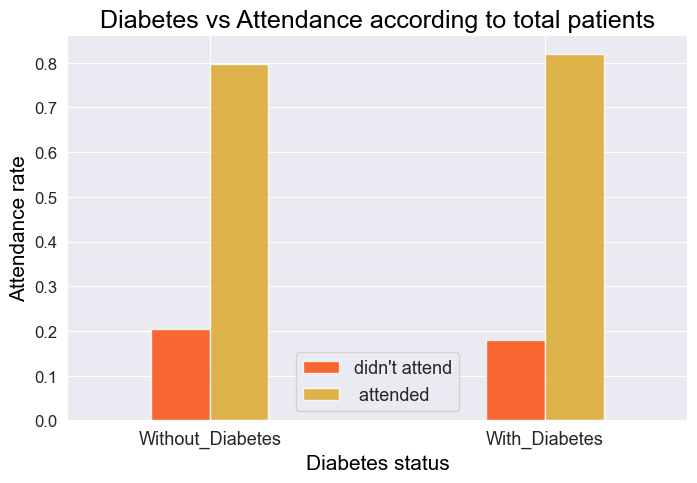

In [47]:
# Bar Chart for proportions of patients who have and don't have Diabetes according to total number of patients

diabetes_proportions.plot(kind = "bar",
                               rot = 0,
                               width = 0.35,
                               color=["orangered","goldenrod"],
                               alpha = 0.8,
                               fontsize = 12,
                               figsize=(8,5)
                                 )
plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Diabetes status",fontsize=15, color="k")
plt.title("Diabetes vs Attendance according to total patients", fontsize=18, color="k")
labels = ['Without_Diabetes', 'With_Diabetes']
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()

### Answer 5

* From above visualisation the attendance rate is rather similar for both patients who have diabetes and don't have diabetes. They have relatively similar commitment to attend the medical appointment.
   - Percentage of patients who have Diabetes and attended is 81.99% from all patients who have Diabetes. 
   - Percentage of patients who don't have Diabetes and attended is 79.63% from all patients who does not have Diabetes. 
   
(That means there's no direct correlation between diabetes and attendance.)


### Research Question 6
> #### How the Scholarship affect probability of show up?
     - Ratio for patients who have Scholarship and attended the appointment.
     - Ratio for patients who don't have Scholarship and attended the appointment.

In [48]:
# Obtaining Scholarship proportions using (proportions_fun)

scholarship_proportions = proportions_fun(df,["Scholarship"],"Show")
scholarship_proportions

Show,0,1
Scholarship,,
0,0.198074,0.801926
1,0.237363,0.762637


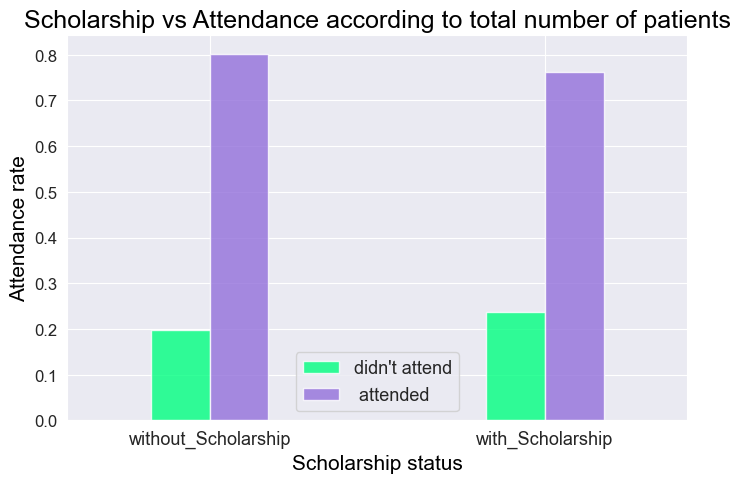

In [49]:
# Chart for proportions of patients who have and don't have scholarship_proportions according to total number of patients

scholarship_proportions.plot(kind = "bar",
                               rot = 0,
                               width = 0.35,
                               color=["springgreen","mediumpurple"],
                               alpha = 0.8,
                               fontsize = 12,
                               figsize=(8,5)
                                 )
plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Scholarship status",fontsize=15, color="k")
plt.title("Scholarship vs Attendance according to total number of patients", fontsize=18, color="k") 
labels = ['without_Scholarship', 'with_Scholarship']
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()

### Answer 6

* From above visualisation, the attendance rate is rather similar for both patients who have and don't have scholarship.They have relatively similar commitment to attend the medical appointment.
   - Percentage of patients who have Scholarship and attended is 76.26% from all patients who have Scholarship. 
   - Percentage of patients who does not have Scholarship and attended is 80.19% from all patients who does not have Scholarship. 
   
(That means there's no direct correlation between scholarship and attendance.)


### Research Question 7
> #### Does receiving SMS affect the attendance?
     - Ratio for patients who received SMS and attended the appointment.
     - Ratio for patients who didn't receive SMS and attended the appointment.

In [50]:
# Obtaining received SMS proportions using (proportions_calc function)

sms_proportions =  proportions_fun(df,["SMS_received"],"Show")
sms_proportions

Show,0,1
SMS_received,,
0,0.167035,0.832965
1,0.275745,0.724255


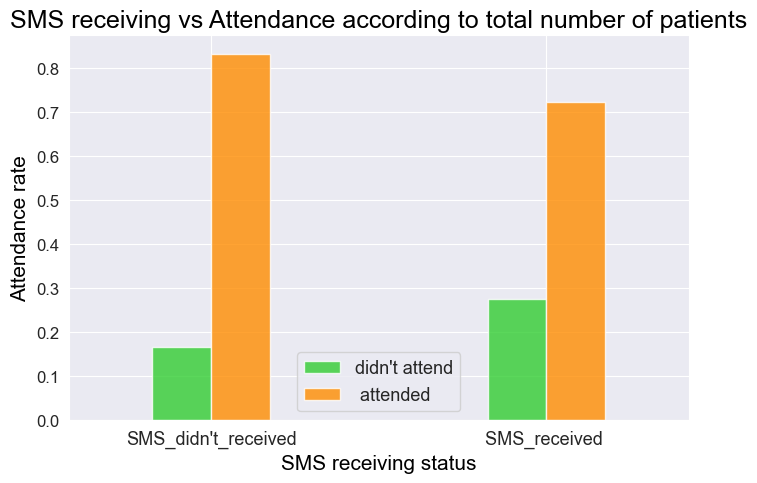

In [51]:
# Bar Chart for proportions of patients who received SMS and who didn't according to total number of patients

sms_proportions.plot(kind = "bar",
                               rot = 0,
                               width = 0.35,
                               color=["limegreen","darkorange"],
                               alpha = 0.8,
                               fontsize = 12,
                               figsize=(8,5)
                                 )
plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("SMS receiving status",fontsize=15, color="k")
plt.title("SMS receiving vs Attendance according to total number of patients", fontsize=18, color="k") 
labels = ["SMS_didn't_received", "SMS_received "]
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()

### Answer 7

* The attendance rate for patient who have not recieved SMS is higher
    - Percentage of patients who have recieved SMS and attended is 72.42% from all patients who recieved SMS. 
    - Percentage of patients who have not recieved SMS and attended is 83.29% from all patients who didn't receive SMS.
* This result is unexpected. Usually the attendance rate of patients who have received SMS is higher.

(That means there's no direct correlation between SMS receiving and attendance.)

### Research Question 8
> #### Does Age affect the attendance?

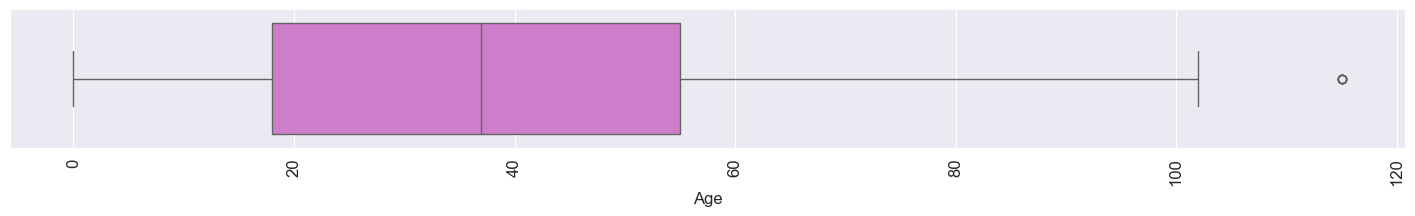

In [52]:
# Boxplot: Age for all patients

plt.figure(figsize=(18,1.8))
plt.xticks(rotation=90)
sns.boxplot(x=df.Age,color="orchid");
plt.show()

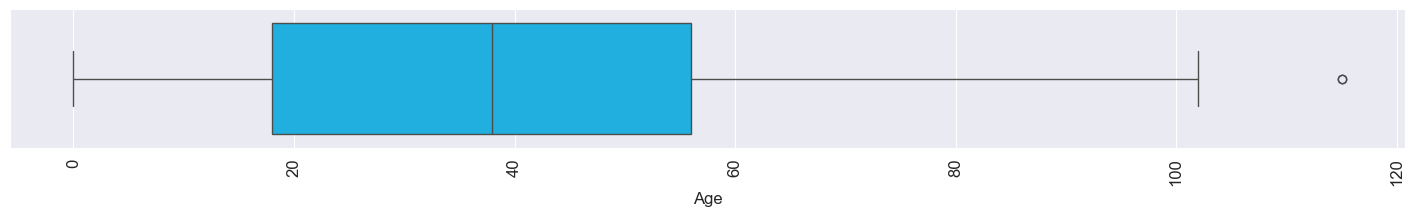

In [53]:
# Boxplot: Age for patient who atteneded only

plt.figure(figsize=(18,1.8))
plt.xticks(rotation=90)
sns.boxplot(x=df_show.Age,color="deepskyblue");
plt.show()

From above boxplots we can see that:

* Maximum age is same for both (115)
* Minimum Age is same for both (0)
* First quartile Age is same for both(18)

* Median Age for total patients is (37)
* Median Age for attended patients is (38)
* Third quartile Age for total patients is (55)
* Third quartile Age for attended patients is (56) 

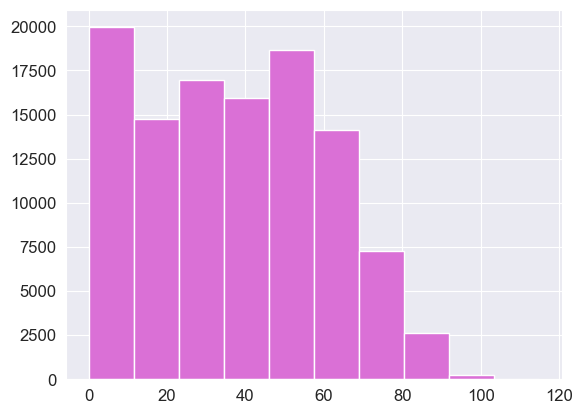

In [54]:
# Checking for Age skewness for all patients

df["Age"].hist(color=["orchid"]);
plt.show();

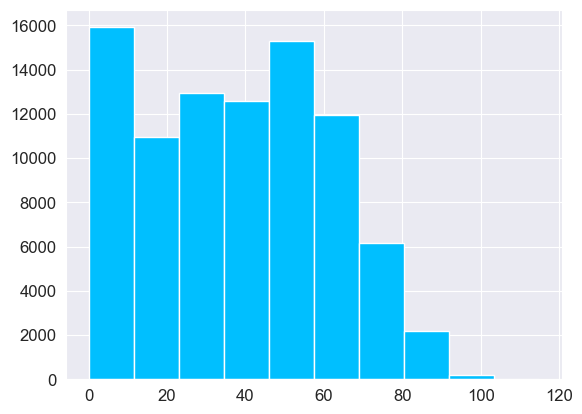

In [55]:
# checking for Age skewness for atteneded patients only

df_show["Age"].hist(color=["deepskyblue"]);
plt.show();

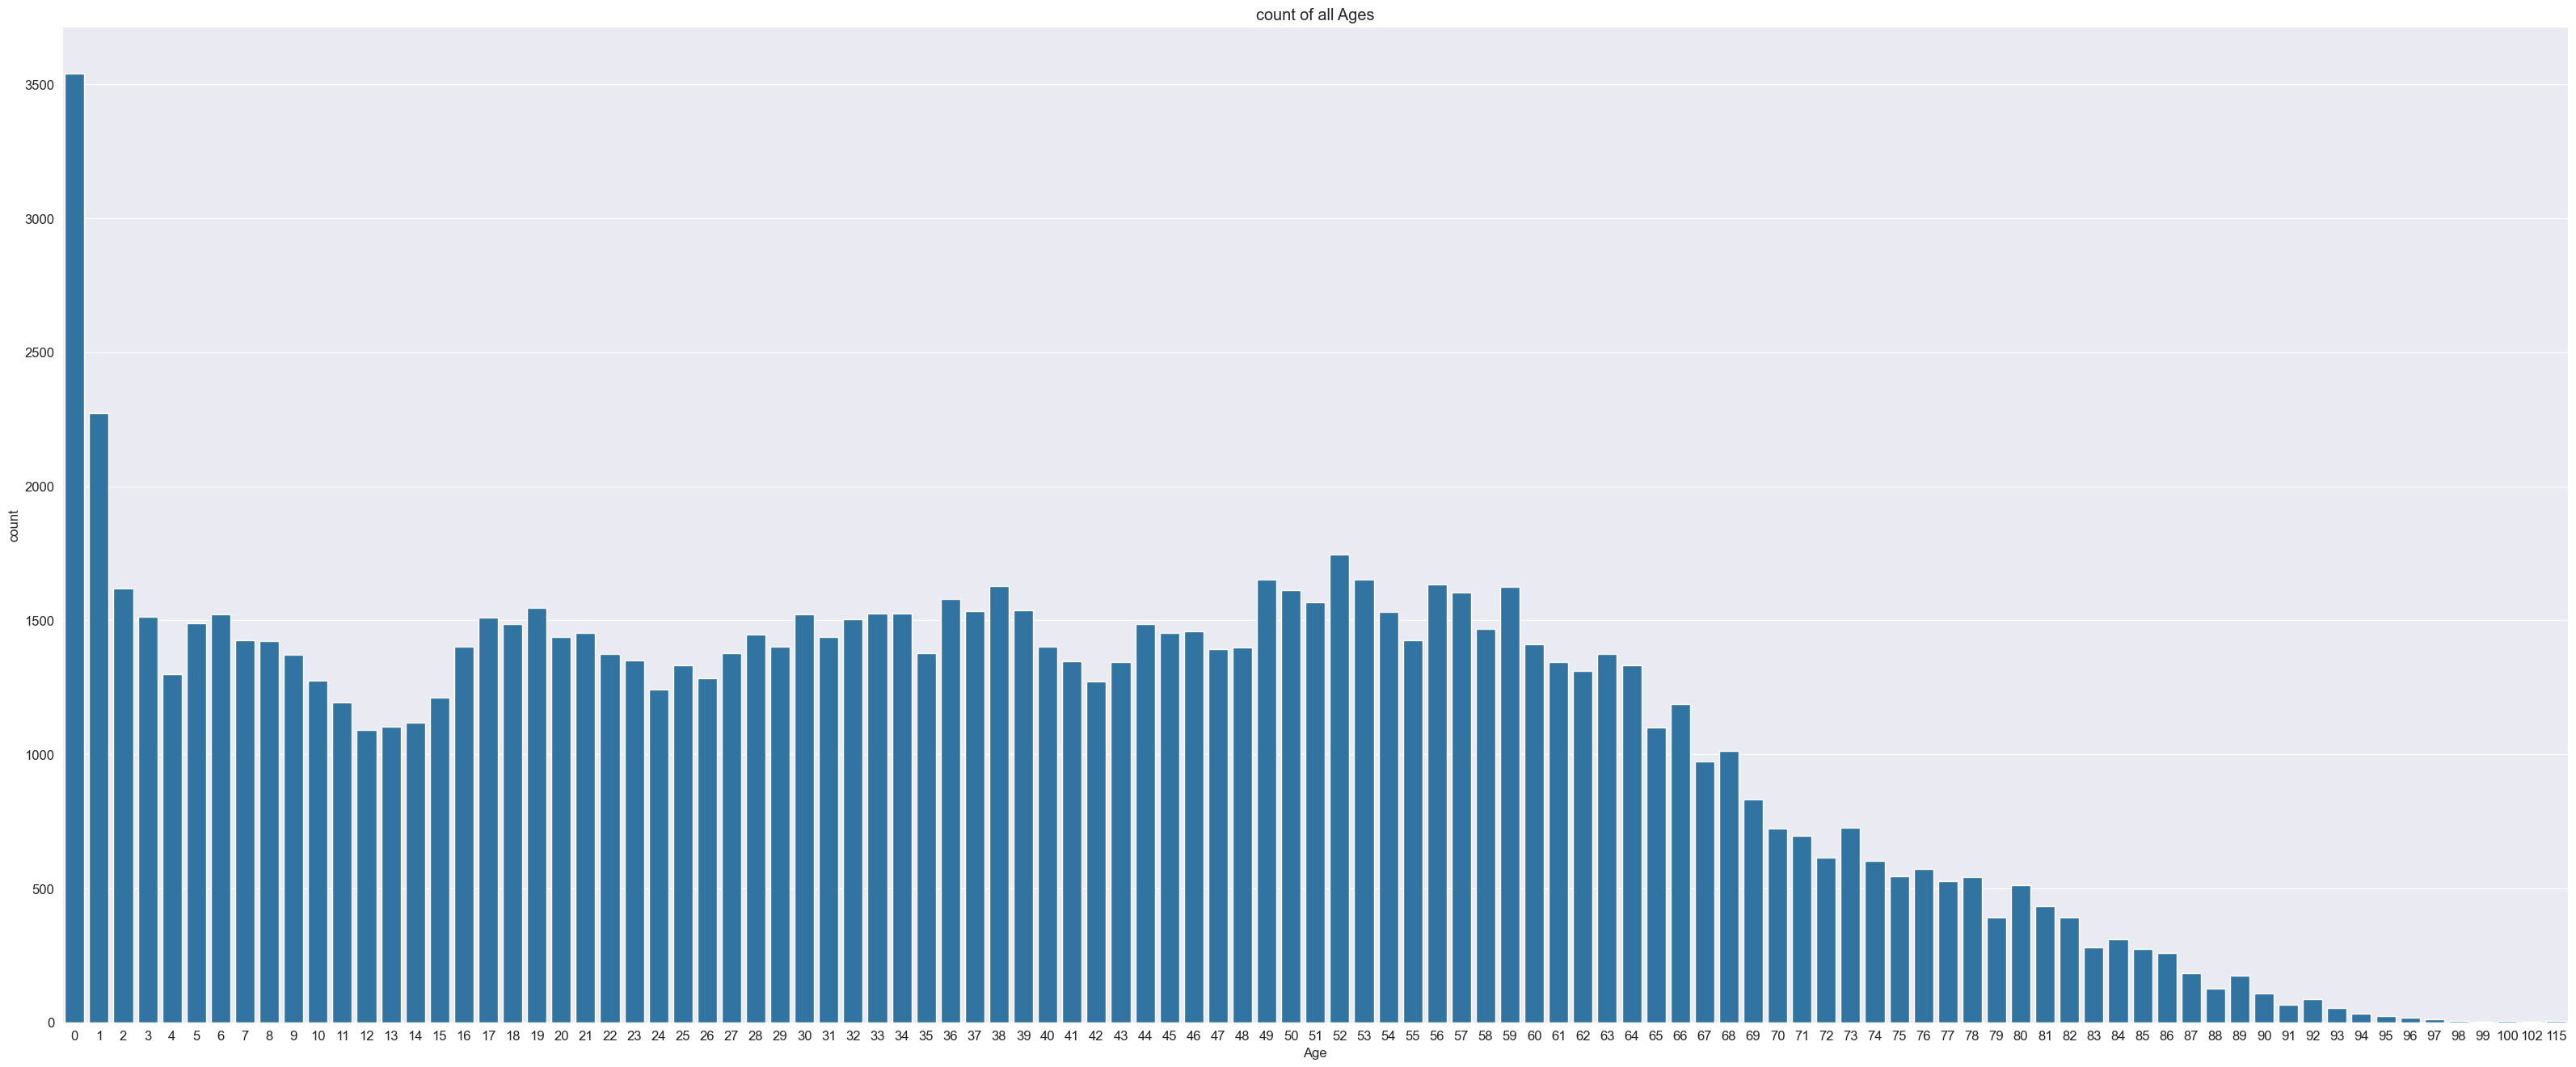

In [56]:
plt.figure(figsize=(40,16))
plt.tight_layout()
sns.countplot(x=df.Age).set_title("count of all Ages")
plt.show();

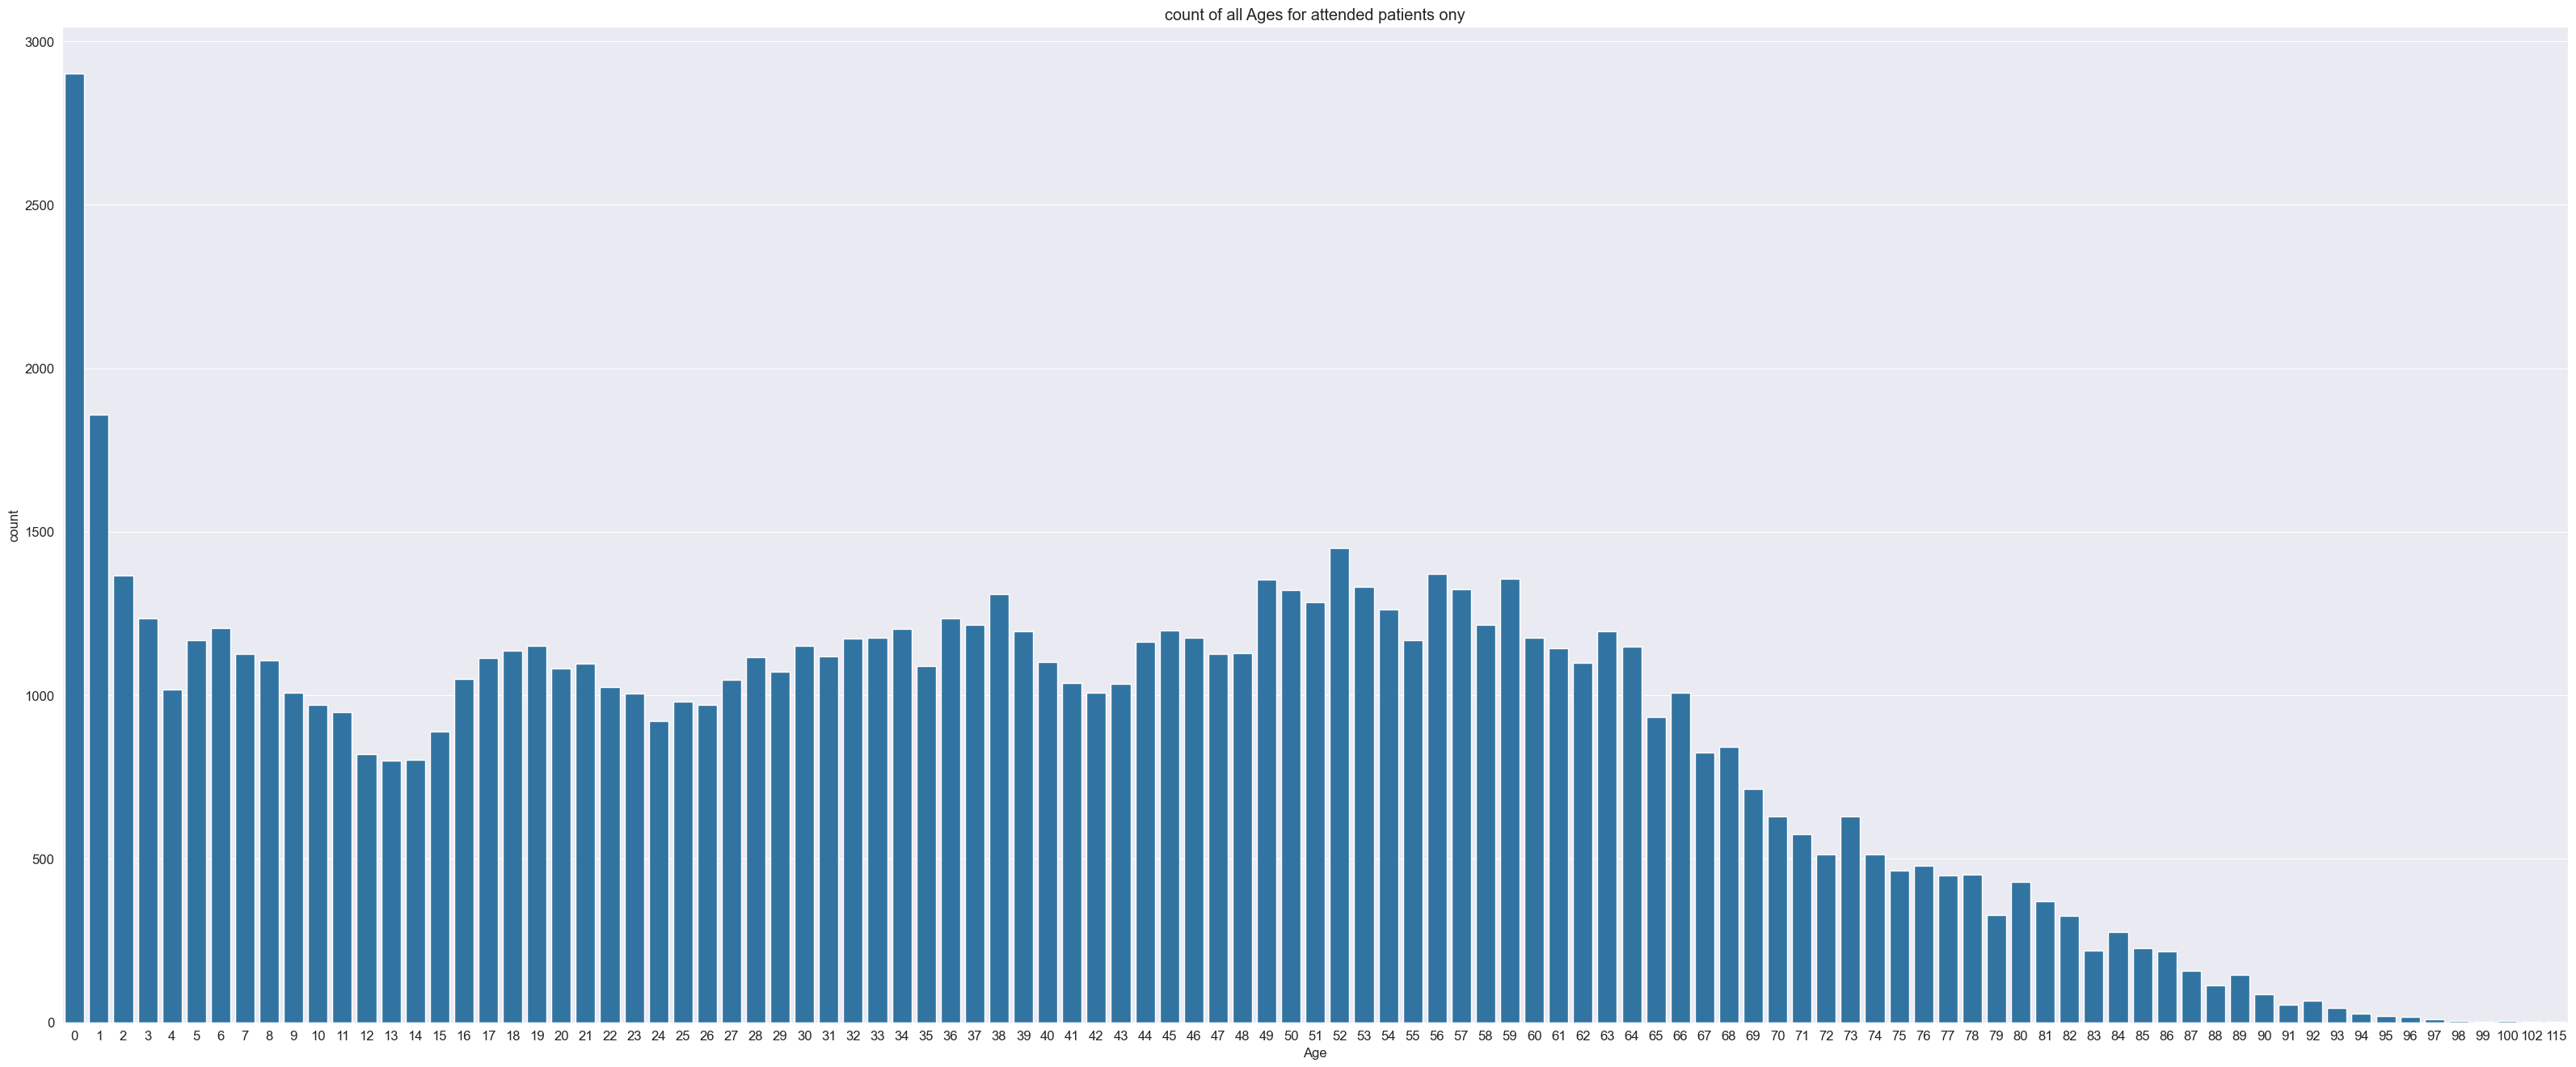

In [57]:
plt.figure(figsize=(40,16))
plt.tight_layout()
sns.countplot(x=df_show.Age)
plt.title("count of all Ages for attended patients ony");
plt.show();

From above visualisations we can see that:
* Count of infants (0 : 2 years) who made appointment is higher compared with other Ages counts
* Count of infants (0 : 2 years) who showed up for appointment is higher compared with other Ages counts

(Therefore, we need to check the proportion for Ages to make certain from the correlation with attendance)

In [58]:
# Obtaining Age proportions using (proportions_calc function)

age_proportions = proportions_fun(df,["Age"],"Show")
age_proportions

Show,0,1
Age,,
0,0.180559,0.819441
1,0.182578,0.817422
2,0.155748,0.844252
3,0.183080,0.816920
4,0.217090,0.782910
...,...,...
98,0.166667,0.833333
99,NaN,1.000000
100,NaN,1.000000


In [59]:
# fill nan values with zero

age_proportions.fillna(0, inplace=True)

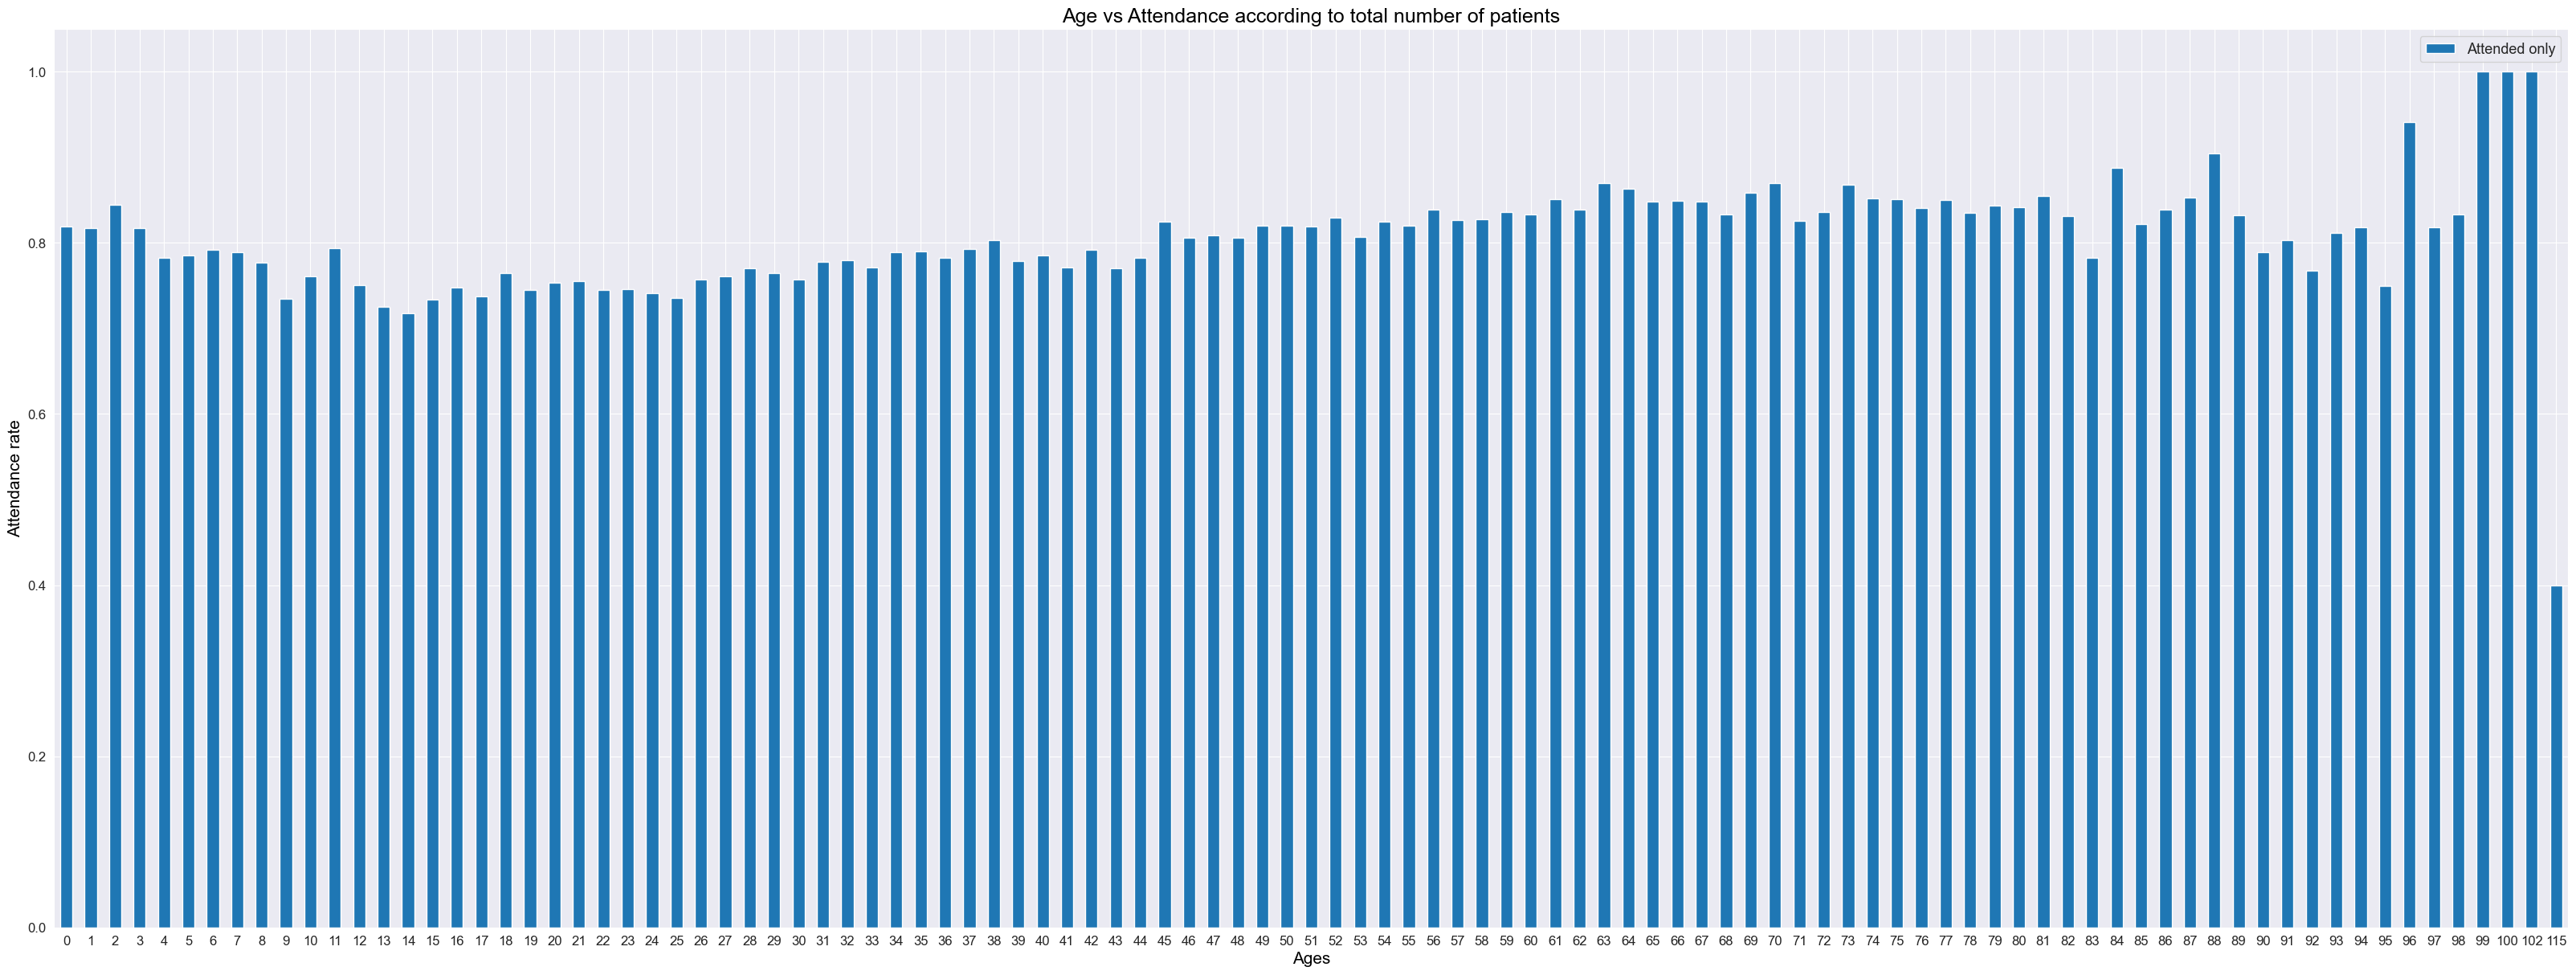

In [60]:
# Bar Chart for Age proportions acording to all patients

age_proportions[1].plot(kind = "bar",
                               rot = 0,
                               alpha = 1,
                               fontsize = 12,
                               figsize=(32,12)
                                 )
plt.tight_layout()
plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Ages",fontsize=15, color="k")
plt.title("Age vs Attendance according to total number of patients", fontsize=18, color="k") 
plt.legend(["Attended only"],fontsize=13);
plt.show()

* From above visualisations we can notice that most of age range attendance ratio is over than 80% but the ratio for teenagers is lower. and the ratio is too high for very old patients so we need to check the count of them to make certain from direct correlation.

In [61]:
df.query("Age>95").shape[0] , df.query("Age>13 & Age < 25").shape[0] 

(46, 15128)

* There are 46 patient older than 95 years with very high attendance ratio.
* There are 15128 patient older than 13 and lower than 25 with low attendance ratio.

Next, I will categorize the data by age group to identify which age category has the highest attendance ratio and which has the lowest attendance ratio.

In [62]:
# Obtaining proportions for age categories (count of category who attended divide by count of total for same category)

proportions_inf = (df_show.query("Age >=0 & Age<=1").count() / df.query("Age >=0 & Age<=1")["Age"].count())["Age"]
proportions_kids= (df_show.query("Age >=2 & Age<=12").count() / df.query("Age >=2 & Age<=12")["Age"].count())["Age"]
proportions_teens= (df_show.query("Age >=13 & Age<=20").count() / df.query("Age >=13 & Age<=20")["Age"].count())["Age"]
proportions_adults= (df_show.query("Age >=21 & Age<=60").count() / df.query("Age >=21 & Age<=60")["Age"].count())["Age"]
proportions_old = (df_show.query("Age >=61").count() / df.query("Age >=61 ")["Age"].count())["Age"]

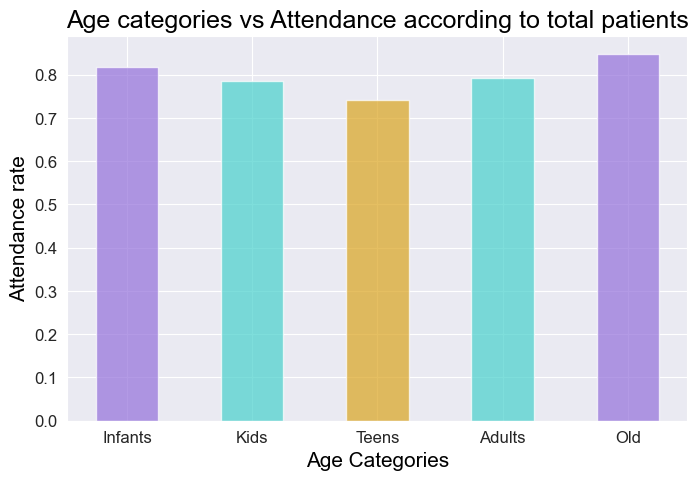

In [63]:
# Bar # Chart for Age categories
age_count_ind = ["Infants","Kids","Teens","Adults","Old"]
hights = [proportions_inf,proportions_kids,proportions_teens,proportions_adults,proportions_old]
width=0.5
plt.figure(figsize=(8,5))
plt.bar(age_count_ind, hights,width,color=["mediumpurple","mediumturquoise","goldenrod","mediumturquoise","mediumpurple"], alpha = .7)
plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Age Categories",fontsize=15, color="k")
plt.title("Age categories vs Attendance according to total patients", fontsize=18, color="k") 
plt.show();

### Answer 8

* Teens patients (13:20 years) category has the lowest attendance ratio (74.20%).
* Old patients (over 60 years) and infant patients (0:2 years) categories have the highest attendance rate:
  - Old ratio is (84.78%).
  - Infant ratio is (81.87%).
* Kids patients (3:12) and adults patients (21:60 years) categories have the relatively moderate attendance rate:
  - Kids ratio is (78.63%).
  - Adult ratio is (79.26%).
  
( From previous visualisation we can conclude that Teeanagers patients' commitment to attend the medical appoinment is low while infants and old peoples' commitment to attend the medical appoinment is high.)



### Research Question 9
> #### Does appointment delay affect the attendance?

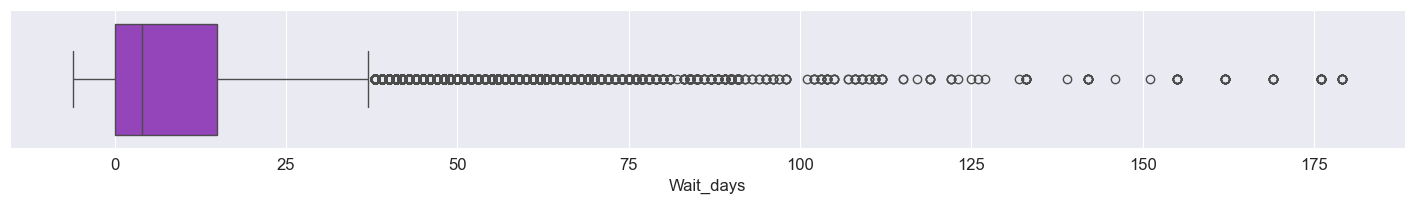

In [64]:
# Boxplot for Wait_days for all patients

plt.figure(figsize=(18,1.8))
sns.boxplot(x=df.Wait_days,color="darkorchid");
plt.show()

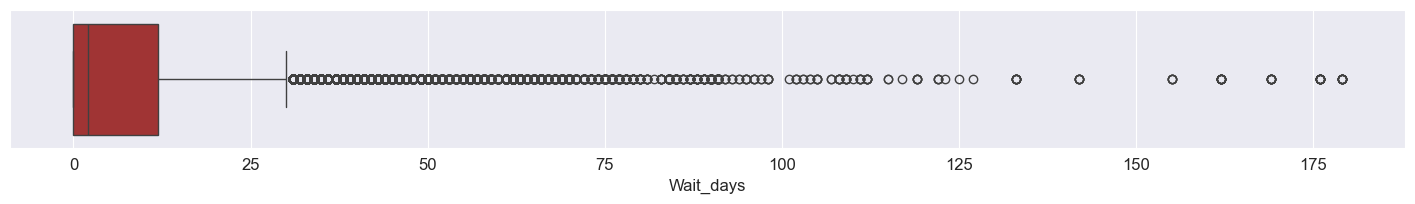

In [65]:
# Boxplot for Wait_days for patients who atteneded only

plt.figure(figsize=(18,1.8))
sns.boxplot(x=df_show.Wait_days,color="firebrick");
plt.show()

From above boxplots we can see that:

* Maximum wait days is same for both (197)
* First quartile wait days is same for both (0)

* Minimum wait days for total patients is (-6)
*  Minimum wait days for attended patients is (0)
* Median wait days for total patients is (4)
* Median wait days for attended patients is (2)
* Third quartile wait days for total patients is (15)
* Third quartile wait days for attended patients is (12) 

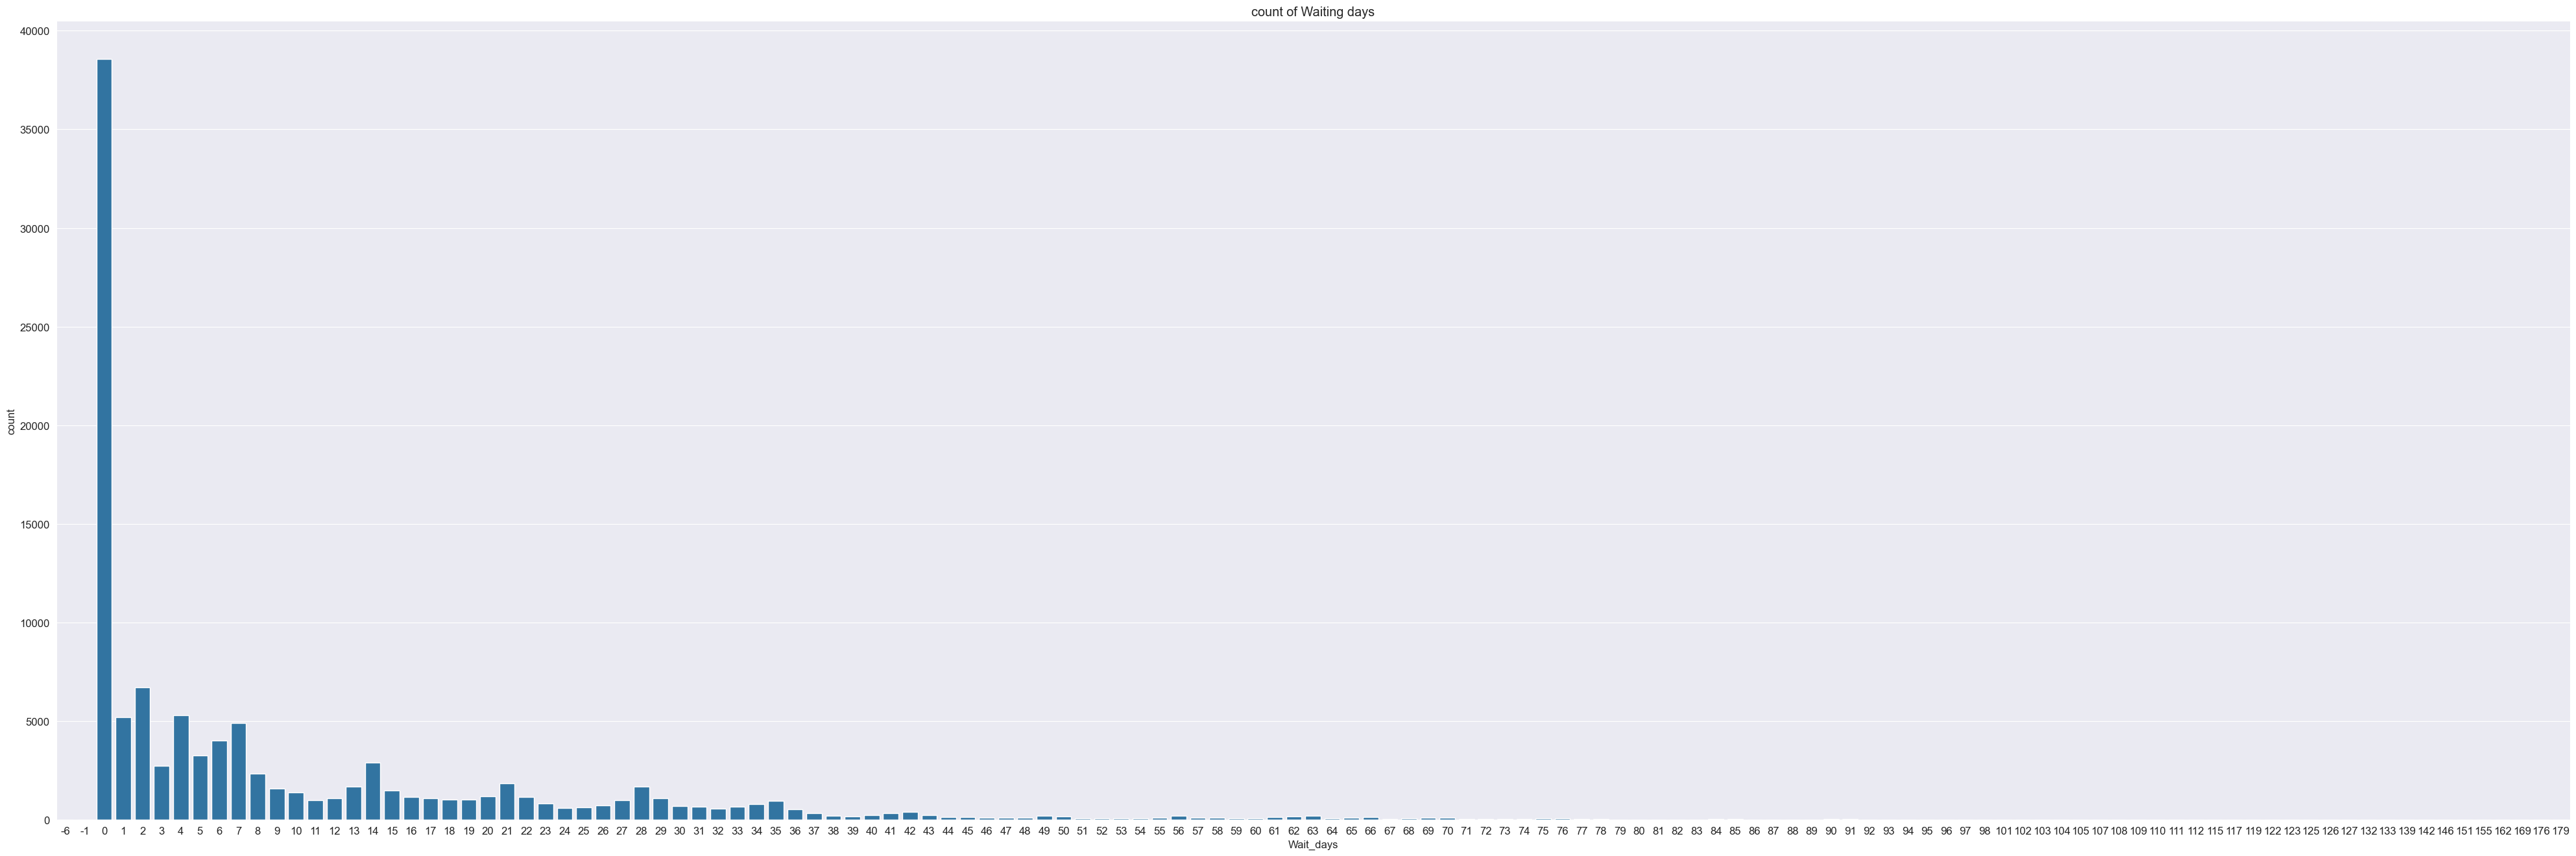

In [66]:
# Count of waiting days for all patients

plt.figure(figsize=(50,16))
plt.tight_layout()
sns.countplot(x=df.Wait_days).set_title("count of Waiting days")
plt.show()

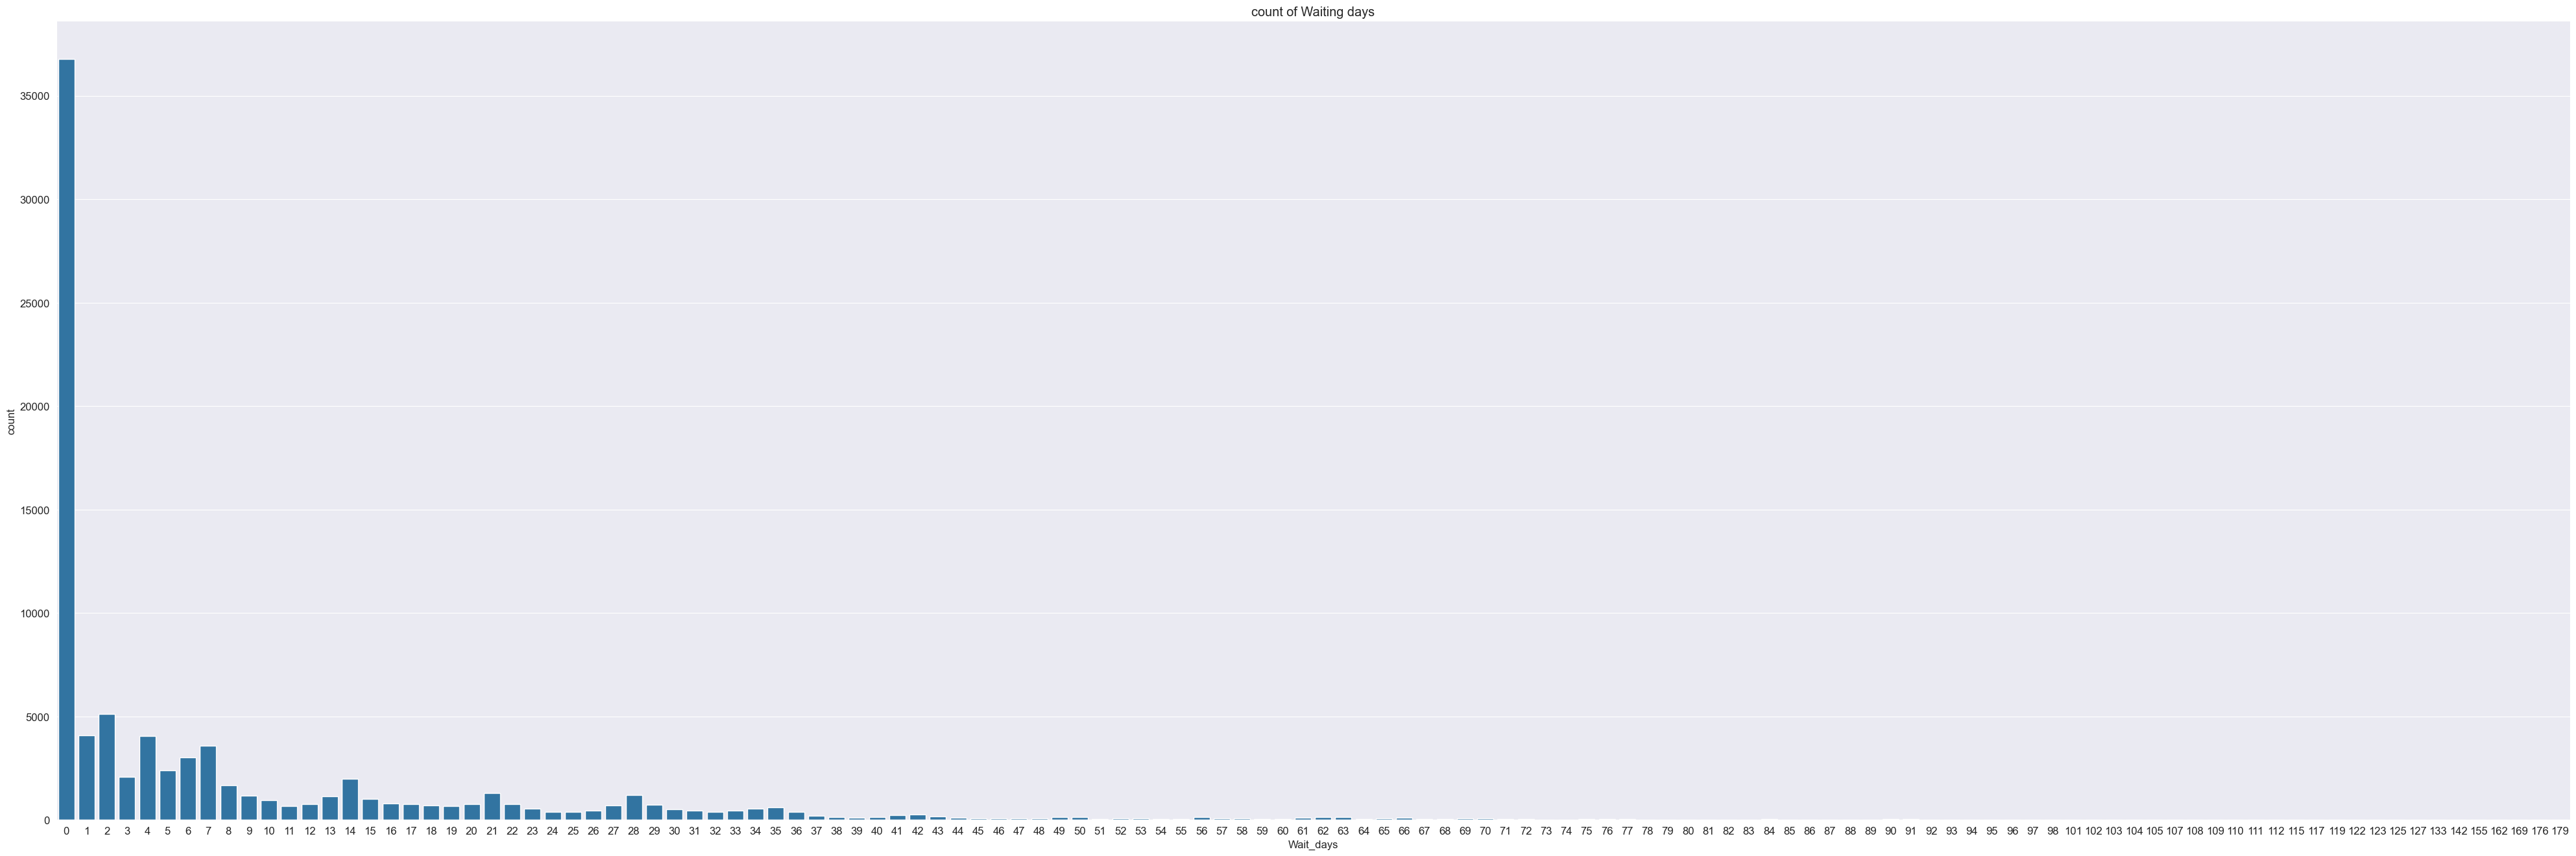

In [67]:
# count of waiting days for attended patients only

plt.figure(figsize=(50,16))
plt.tight_layout()
sns.countplot(x=df_show.Wait_days).set_title("count of Waiting days")
plt.show()

From above visualisations we can see that:

* Count of patients who have no wating days at all and showed up for appointment is high (over 35000 patient)
* Count of patients is lower when wating days is higher

(Therefore, we need to check the proportion for wating days to make certain from the correlation with attendance)

In [68]:
# Obtaining wait_days_proportions using (proportions_fun)

wait_days_proportions = proportions_fun(df,["Wait_days"],"Show")
wait_days_proportions

Show,0,1
Wait_days,,
-6,1.000000,NaN
-1,1.000000,NaN
0,0.046471,0.953529
1,0.213505,0.786495
2,0.238216,0.761784
...,...,...
155,0.600000,0.400000
162,0.181818,0.818182
169,0.125000,0.875000


In [69]:
# fill nan values with 0
wait_days_proportions.fillna(0, inplace=True)

In [70]:
wait_days_proportions[0]

Wait_days
-6      1.000000
-1      1.000000
 0      0.046471
 1      0.213505
 2      0.238216
          ...   
 155    0.600000
 162    0.181818
 169    0.125000
 176    0.375000
 179    0.200000
Name: 0, Length: 131, dtype: float64

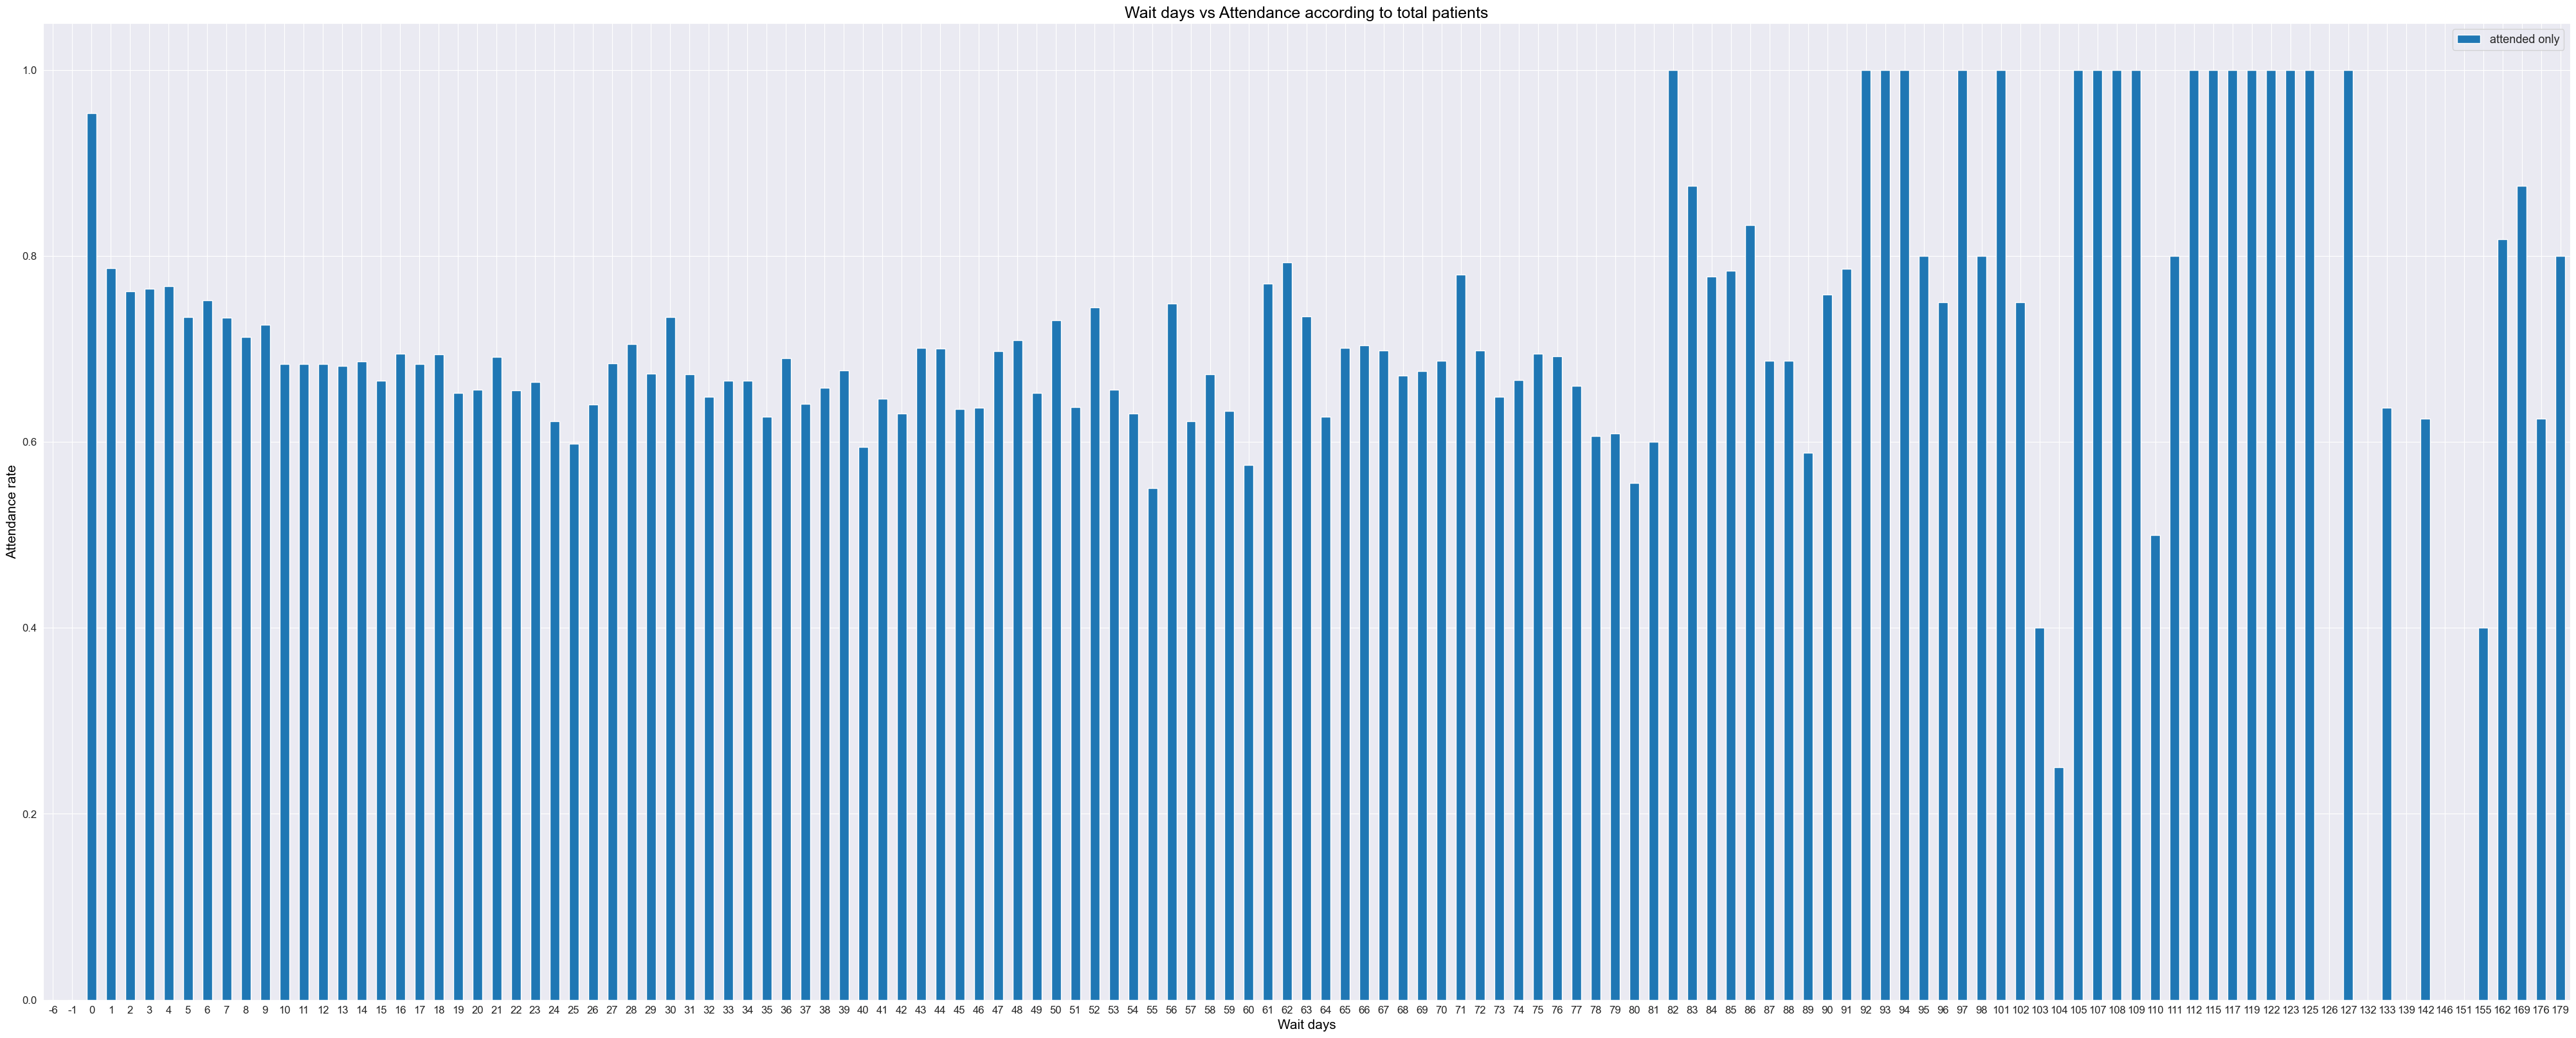

In [71]:
# Bar Chart for wait days proporation 

wait_days_proportions[1].plot(kind = "bar",
                               rot = 0,
                               alpha = 1,
                               fontsize = 12,
                               figsize=(40,16)
                                 )
plt.tight_layout()
plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Wait days",fontsize=15, color="k")
plt.title("Wait days vs Attendance according to total patients", fontsize=18, color="k") 
plt.legend(["attended only"],fontsize=13);
plt.show();

### Answer 9

From the above visualization we can see that most patient who has 0 wait days attended to the appointment. Their attendance ratio is around 95%. The count of patients with high waiting days is low as we shown on previous count bar chart.

(We can conclude that there's no direct relation between appointment delay and attendance but for sure if wait time is 0 the patients will most likely attend. This factor is very important and can help us alot to make better prediction)

### Extra research
> #### After examining the relationship between each individual feature and the attendance status (show/no-show), no strong or direct correlation was identified. Therefore, the next step is to analyze the combined effect of two factors to determine whether their interaction has a greater influence on patient attendance.

In [72]:
# The impact of ALcoholism and gender on attendance using (proportions_fun)

gender_alcoholism_proportions = proportions_fun(df,["Gender","Alcoholism"],"Show")
gender_alcoholism_proportions

Show                      0         1
Gender Alcoholism                    
F      0           0.202305  0.797695
       1           0.251840  0.748160
M      0           0.201259  0.798741
       1           0.172672  0.827328

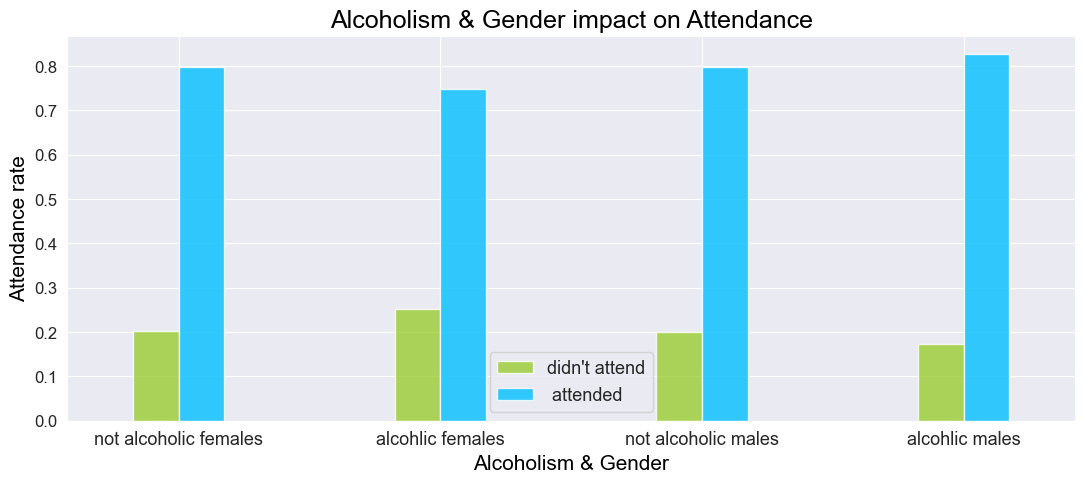

In [73]:
# Bar chart for ALcoholism and gender impact on attendance

gender_alcoholism_proportions.plot(kind = "bar",
                               rot = 0,
                               width = 0.35,
                               color=["yellowgreen","deepskyblue"],
                               alpha = 0.8,
                               fontsize = 12,
                               figsize=(13,5)
                                 )
plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Alcoholism & Gender",fontsize=15, color="k")
plt.title("Alcoholism & Gender impact on Attendance", fontsize=18, color="k") 
labels = ['not alcoholic females',"alcohlic females",'not alcoholic males',"alcohlic males"]
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()

In [74]:
# The impact of ALcoholism and scholarship on attendance using (proportions_fun)

alcoholism_scholarship_proportions = proportions_fun(df,["Alcoholism","Scholarship"],"Show")
alcoholism_scholarship_proportions

Show                           0         1
Alcoholism Scholarship                    
0          0            0.198414  0.801586
           1            0.235072  0.764928
1          0            0.186441  0.813559
           1            0.282197  0.717803

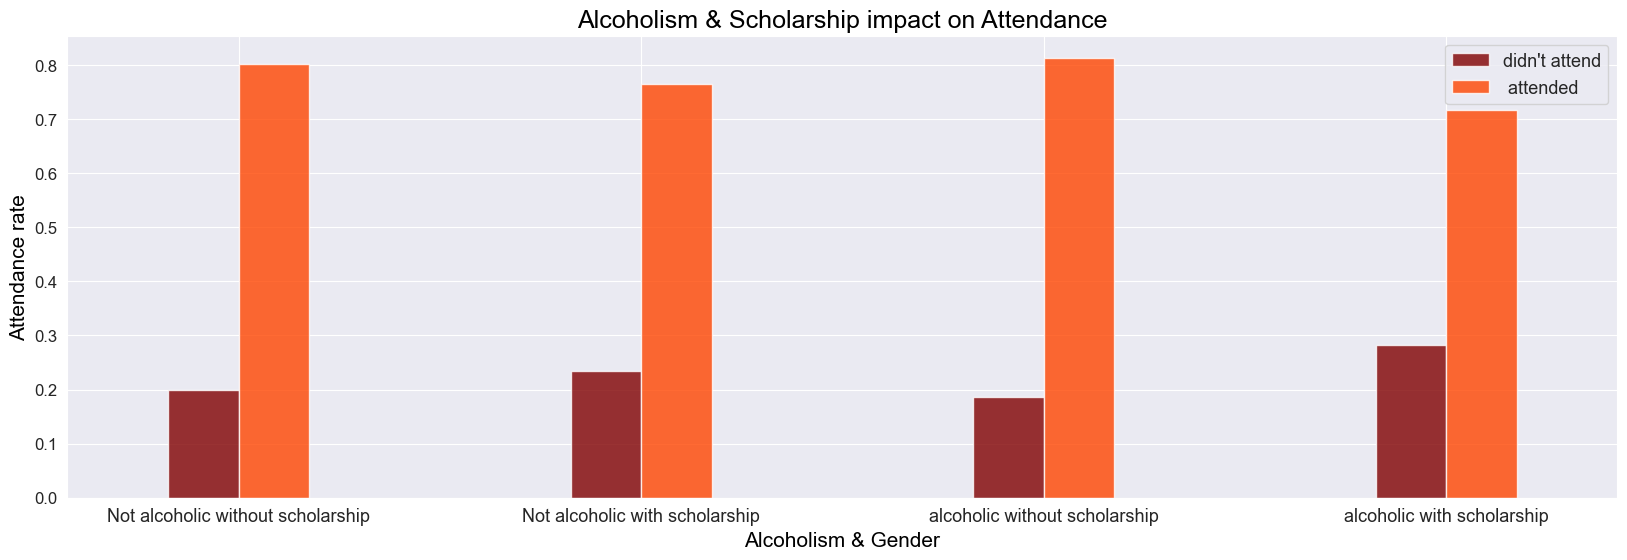

In [75]:
alcoholism_scholarship_proportions.plot(kind = "bar",
                               rot = 0,
                               width = 0.35,
                               color=["maroon","orangered"],
                               alpha = 0.8,
                               fontsize = 12,
                               figsize=(20,6)
                                 )
plt.ylabel("Attendance rate",fontsize=15, color="k")
plt.xlabel("Alcoholism & Gender",fontsize=15, color="k")
plt.title("Alcoholism & Scholarship impact on Attendance", fontsize=18, color="k") 
labels = ['Not alcoholic without scholarship',"Not alcoholic with scholarship",'alcoholic without scholarship',"alcoholic with scholarship"]
plt.xticks(range(len(labels)),labels, fontsize=13);
plt.legend(["didn't attend"," attended"],fontsize=13);
plt.show()

## Extra research Answer

* The attendance rate for Females who have Alcoholism is the lowest.
    - Females patients who have Alcoholism are attending with 74.81% rate.
    - Male patients who have Alcoholism are attending with 82.73% rate.
    - Females patients who does not have Alcoholism are attending with 79.76% rate.
    - Male patients who does not have Alcoholism are attending with 79.87%.
    
* The attendance rate for Alcoholic patients who have scholarship is the lowest.
    - Not Alcoholic patients without Scholarship are attending with 80.16%.
    - Not Alcoholic patients with Scholarship are attending with 76.49%.
    - Alcoholic patients without Scholarship are attending with 81.36%.
    - Alcoholic patients with Scholarship are attending with 71.78%.

<a id='conclusion'></a>

## Conclusion of the Exploratory Data Analysis (EDA)

The key findings from the exploratory data analysis are summarized below:

- **Overall attendance:** The overall attendance rate is **79.8%**, while **20.2%** of patients did not attend their scheduled appointments.
- **Gender distribution:**
  - Female patients account for **64.9%** of all attended appointments.
  - Male patients account for **35.1%** of all attended appointments.
  - However, **gender does not appear to have a significant impact on attendance**.
- **Medical conditions:**
  - **Alcoholism** shows no clear relationship with attendance.
  - **Hypertension** shows no clear relationship with attendance.
  - **Diabetes** shows no clear relationship with attendance.
  - **Disability (Handicap)** generally shows no clear relationship with attendance. Although patients with Disability Level 4 had a lower attendance rate, this group consisted of only **three patients**, making the result unreliable.
- **Scholarship:** Scholarship status does not appear to influence attendance, although this finding is somewhat unexpected.
- **SMS reminders:** Receiving an SMS reminder does not show a positive relationship with attendance. In fact, patients who did **not** receive an SMS reminder had a slightly higher attendance rate, which is also an unexpected finding.
- **Age:** Age appears to influence attendance. Teenagers have the lowest attendance rates, whereas infants and older adults tend to have higher attendance rates.
- **Appointment waiting time:** Although there is no strong linear relationship between waiting time and attendance, appointments scheduled with **zero waiting time** have the highest attendance rate. This suggests that reducing appointment delays could improve attendance and may be an important feature for predictive modeling.

## Limitations

The following limitations were identified during the exploratory data analysis:

- **Age as a confounding factor:** The age distribution is highly imbalanced and may influence the relationship between attendance and other variables such as **hypertension, diabetes, alcoholism, and gender**. This makes it difficult to accurately measure the independent effect of these variables on attendance.
  - **7,430** patients are infants (0–2 years).
  - **13,196** patients are children (3–13 years).

- **Data quality issues in the Age column:**
  - One record contains an invalid age of **-1 year**.
  - Five records have an age of **115 years**, which may represent data entry errors and should be verified.

- **Limitations of the appointment date variables:**
  - The **AppointmentDay** column contains only the appointment date, without the appointment time (hours, minutes, or seconds), limiting time-based analyses.
  - Some patients experienced exceptionally long waiting times (up to **197 days**). Since the dataset does not explain the reasons for these delays, it is difficult to determine their impact or identify possible improvements.

- **Confusing target variable labels:** The **No-show** column uses **"No"** to indicate that a patient attended the appointment and **"Yes"** to indicate that the patient missed the appointment. This labeling is counterintuitive and requires careful interpretation during the analysis.

<a id='model'></a>
## Predictive Model Development

Before training our model, we must prepare the dataset specifically for machine learning. This involves:
1. **Feature Selection & Target Alignment:** Defining our target variable so that `1` represents a "No-Show" (the class we want to predict), and dropping unreadable datetime features. This is because in machine learning, it is an academic standard to make the class of interest (the anomaly/minority class) the positive class (1). Since the hospital wants to predict and intervene on No-Shows, "Missed" must equal 1.
2. **Categorical Encoding:** Converting text-based variables (like `Gender` and `Neighbourhood`) into numerical formats using One-Hot Encoding.
3. **Handling Class Imbalance:** The dataset has an 80/20 split (Attended vs. Missed). If left untreated, the model will be biased toward predicting "Attended" for everyone. We will fix this by splitting our data into Training/Testing sets, and then applying **SMOTE (Synthetic Minority Over-sampling Technique)** strictly to the training data.

In [76]:
# Target Alignment: Create a 'Target' column where Missed = 1 and Attended = 0
# Currently in 'Show': 1 means Attended, 0 means Missed. We invert this.
df_verification['Target'] = (df_verification['Show'] == 0).astype(int)

# Drop Datetime columns, the old 'Show' column, and any remaining IDs
columns_to_drop = ['Scheduled_day', 'Appointment_day', 'Show', 'PatientId'] # Ensure PatientId is dropped if it still exists
df_ml = df_verification.drop(columns=[col for col in columns_to_drop if col in df_verification.columns], axis=1)

# Verify the new ML-ready dataframe
print(df_ml.dtypes)
display(df_ml.head())

Gender                      object
Age                          int64
Neighbourhood               object
Scholarship                  int64
Hipertension                 int64
Diabetes                     int64
Alcoholism                   int64
Handcap                      int64
SMS_received                 int64
Wait_days                    int32
historical_no_show_rate    float64
Target                       int32
dtype: object


,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Wait_days,historical_no_show_rate,Target
0,F,61,JARDIM CAMBURI,0,0,0,0,0,0,8,0.0,0
1,F,17,MARIA ORTIZ,0,0,0,0,0,0,2,0.5,0
2,F,55,SÃO JOSÉ,0,1,0,0,0,0,0,0.5,0
3,M,11,CONQUISTA,0,0,0,0,0,1,7,0.2,0
4,M,7,JARDIM DA PENHA,0,0,0,0,0,1,28,0.0,0


### Encoding Categorical Variables & Train-Test Split
Next, we separate our features (`X`) from our target (`y`). We then apply `pd.get_dummies()` to convert categorical columns (like `Gender` and `Neighbourhood`) into machine-readable binary columns (1s and 0s). 

Finally, we split the data 80/20. **Crucially, we must split the data BEFORE applying SMOTE.** This ensures that synthetic data is not leaked into the testing set, preserving the integrity of our final evaluation.

In [77]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df_ml.drop('Target', axis=1)
y = df_ml['Target']

# One-Hot Encode categorical features (drop_first=True avoids multicollinearity)
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/Test Split (80% Training, 20% Testing)
# stratify=y ensures the 80/20 imbalance ratio is maintained in both splits before balancing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (88420, 90)
Testing Features Shape: (22106, 90)


### Handling Class Imbalance with SMOTE
We will use SMOTE to synthetically generate new examples of the minority class (No-Shows) within the training data until both classes are equal. This forces the model to learn the mathematical patterns of patients who miss their appointments, rather than just guessing the majority class.

In [78]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

# Initialize and apply SMOTE only on the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
Target
0    70565
1    17855
Name: count, dtype: int64


e:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "e:\Anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "e:\Anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^


After SMOTE:
Target
1    70565
0    70565
Name: count, dtype: int64


### Justification for Random Forest Classifier

For this predictive task, a **Random Forest** algorithm was selected over simpler models (like Logistic Regression) or heavier models (like Deep Learning) for several strategic reasons:

1. **Handling Non-Linearity & Mixed Data:** Healthcare data is inherently non-linear. The relationship between `Age`, `Wait_days`, and categorical variables (like `Hipertension` or `Neighbourhood`) is complex. Random Forests handle both numerical and one-hot encoded categorical data exceptionally well without requiring extensive feature scaling.
2. **Robustness to Overfitting:** By assembling multiple decision trees and using techniques like bagging, the model reduces the variance and overfitting that a single, deep decision tree would suffer from.
3. **Interpretability (Feature Importance):** In a real-world hospital setting, stakeholders need to know *why* predictions are made. Random Forests allow us to extract feature importance, showing exactly which patient attributes most heavily influence a no-show.
4. **Deployment Constraints:** As this project requires deployment via FastAPI and GitHub, we were able to strictly constrain the model's architecture (`n_estimators=75`, `max_depth=10`) to keep the serialized `.joblib` file lightweight while maintaining predictive power.

### Model Training (Size-Constrained Random Forest)
Because this model will be deployed via Render and hosted on GitHub, the serialized model file is suggested to remain under 20MB. Standard Random Forests can easily exceed 100MB if allowed to grow indefinitely. 

To prevent this, we will instantiate a `RandomForestClassifier` with constrained hyperparameters:
* `n_estimators=75`: Uses 75 trees instead of the default 100.
* `max_depth=10`: Prevents trees from growing too deep and memorizing noise.
* `min_samples_split=10`: Requires at least 10 samples to create a new branch.

We will train this model on our SMOTE-balanced training set and evaluate it on the untouched testing set.

Training the model... this may take a few seconds.
Accuracy: 0.6232

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.59      0.71     17642
           1       0.32      0.75      0.44      4464

    accuracy                           0.62     22106
   macro avg       0.61      0.67      0.58     22106
weighted avg       0.78      0.62      0.66     22106



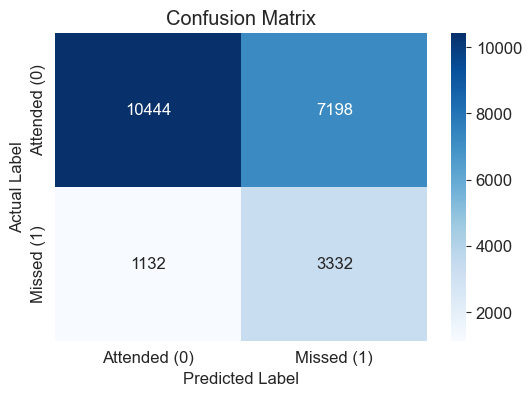

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the size-constrained model
rf_model = RandomForestClassifier(
    n_estimators=75,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1 # Uses all processor cores for faster training
)

# Train the model on the balanced data
print("Training the model... this may take a few seconds.")
rf_model.fit(X_train_balanced, y_train_balanced)

# Generate predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Attended (0)', 'Missed (1)'], 
            yticklabels=['Attended (0)', 'Missed (1)'])
plt.title("Confusion Matrix")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Model Performance Interpretation

At first glance, an overall **Accuracy of 62.32%** may appear modest, especially given the dataset's original 80/20 class imbalance. However, because we applied SMOTE to balance the training data, overall accuracy is no longer the correct metric for success. Instead, we must look at the **Precision and Recall for Class 1 (Missed Appointments)**.

* **Recall for Class 1 (0.75):** This is the strongest and most important metric in our model. A recall of 75% means that out of all the patients who *actually* missed their appointments, our model successfully identified 75% of them. In a hospital setting, missing a true no-show is costly.
* **Precision for Class 1 (0.32):** This metric is lower. It indicates that when our model predicts a patient will miss their appointment, it is correct about 32% of the time. This results in a high number of False Positives (patients who are flagged as no-shows but actually attend). 
* **F1-Score (0.44):** The F1-score balances precision and recall, reflecting the trade-off we made during the SMOTE balancing phase.

**Business Context & Conclusion:**
This model is highly effective for its intended agentic workflow. In an automated intervention system (e.g., sending an outreach message via OpenClaw), the cost of a **False Positive** (sending a reminder to someone who was going to attend anyway) is negligible. However, the cost of a **False Negative** (failing to identify a patient who ends up missing their slot) results in lost revenue and wasted doctor hours. By prioritizing a high Recall (75%), this model successfully catches the vast majority of at-risk patients, triggering the necessary workflow interventions.

### Model Serialization (`joblib`) & Size Verification
With the model trained and evaluated, we will now serialize it. We use `joblib.dump` with the `compress` argument. A compression level of 3 utilizes zlib to significantly shrink the file size without slowing down the load time during FastAPI deployment.

In [80]:
import joblib
import os

# Define the filename
model_filename = 'missed_appointment_model.joblib'

# Save the model with compression level 3
# compress=3 is the sweet spot for maximum size reduction with fast read times
joblib.dump(rf_model, model_filename, compress=3)

# Verify the file size
file_size_bytes = os.path.getsize(model_filename)
file_size_mb = file_size_bytes / (1024 * 1024)

print(f"Model saved successfully as '{model_filename}'")
print(f"File Size: {file_size_mb:.2f} MB")

Model saved successfully as 'missed_appointment_model.joblib'
File Size: 0.81 MB


<a id='deployment'></a>
## Model Deployment (FastAPI & Render)

To fulfill the deployment requirements and make this model accessible for the agentic n8n workflow, the model was transitioned from a local notebook environment to a cloud-hosted REST API.

**Deployment Architecture:**
1. **Model Artifact:** The size-constrained Random Forest model was serialized using `joblib` (`noshow_model.joblib`).
2. **Backend Framework (FastAPI):** A `main.py` script was authored using FastAPI to expose a POST endpoint (`/predict`). Pydantic was used for strict data validation of incoming patient profiles.
3. **Dynamic Encoding:** To handle the high dimensionality of the `Neighbourhood` feature, the FastAPI script dynamically aligns incoming JSON data with the exact One-Hot Encoded columns the Scikit-Learn model expects using `.reindex()`.
4. **Cloud Hosting (Render):** The project was pushed to GitHub and deployed as a Web Service on Render. The service runs using Uvicorn bound to Render's dynamic `$PORT` environment variable.

The API is now live and can be programmatically accessed via HTTP POST requests, returning a JSON payload containing the `prediction` and the specific `no_show_probability`.